# Vise Portfolio Strategy — Comparative Analysis
### UT Austin MSBA // Vise Capstone

---

## Objective

This notebook runs a full combinatorial backtest across:
- **2 portfolios**: 40/60 and 100/0 (Target Allocation ETF family, date 2025-05-20, with historical replacements)
- **3 time periods**: Bear market (2007–2008), Baseline (2010–2019), Bull market (2023–2024)
- **= 6 portfolio × period combinations**

Within each combination, all strategy variants are stacked:
- **TLH**: off (benchmark) vs on (10% loss threshold)
- **Calendar rebalancing**: Monthly, Quarterly, Yearly
- **Absolute threshold rebalancing**: 5%, 10%, 20%
- **Relative threshold rebalancing**: 25%, 50%

Total strategies per combination: 8 (3 calendar + 5 threshold) × 2 (TLH on/off) = **16 runs**  
Total runs: 6 × 16 = **96 runs**

Each no-TLH run is the benchmark for its TLH counterpart — tracking error and information ratio measure the TLH value-add.

---

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS & EMBEDDED ENGINE FUNCTIONS
# Engine functions are embedded directly to avoid importing the Streamlit app
# (portfolio_returns_engine.py) which fails outside a Streamlit context.
# Only optimizer_msba_v1_engine.py is imported — it is a pure Python module.
# ══════════════════════════════════════════════════════════════════════════════

import os, sys, warnings, itertools
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Resolve paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath(''))
REPO_ROOT    = NOTEBOOK_DIR.parent
DATA_DIR     = REPO_ROOT.parent.parent / 'data'
if not DATA_DIR.exists():
    DATA_DIR = REPO_ROOT / 'data'

sys.path.insert(0, str(REPO_ROOT))
from optimizer_msba_v1_engine import run_optimizer_simulation

# ══════════════════════════════════════════════════════════════════════════════
# EMBEDDED ENGINE FUNCTIONS  (extracted from portfolio_returns_engine.py V4)
# ══════════════════════════════════════════════════════════════════════════════

def _get_rebalance_dates(trading_dates, freq):
    """Return set of rebalance dates for a given calendar frequency."""
    dates = pd.DatetimeIndex(trading_dates)
    if len(dates) < 2:
        return set()
    if freq == 'Daily':
        return set(dates[1:])
    rebal_set = set()
    prev_month = dates[0].month
    prev_year  = dates[0].year
    prev_week  = dates[0].isocalendar()[1]
    if freq == 'Weekly':
        for dt in dates[1:]:
            iso = dt.isocalendar()
            if iso[1] != prev_week or dt.year != prev_year:
                rebal_set.add(dt); prev_week = iso[1]; prev_year = dt.year
    elif freq == 'Monthly':
        for dt in dates[1:]:
            if dt.month != prev_month or dt.year != prev_year:
                rebal_set.add(dt); prev_month = dt.month; prev_year = dt.year
    elif freq == 'Quarterly':
        for dt in dates[1:]:
            if dt.month in {1, 4, 7, 10} and (dt.month != prev_month or dt.year != prev_year):
                rebal_set.add(dt)
            if dt.month != prev_month or dt.year != prev_year:
                prev_month = dt.month; prev_year = dt.year
    elif freq == 'Yearly':
        for dt in dates[1:]:
            if dt.year != prev_year:
                rebal_set.add(dt); prev_month = dt.month; prev_year = dt.year
    else:
        raise ValueError(f'Unknown rebalance frequency: {freq}')
    return rebal_set


def build_rebalanced_series(prices_wide, target_weights, initial_capital, rebalance_freq,
                            cost_bps=12.0):
    """
    Calendar-only rebalancing engine (V3). Returns (rebal_daily, rebal_stats).

    cost_bps : total one-way transaction cost in basis points (commission + slippage + spread).
               Default 12 bps = 5 commission + 5 slippage + 2 bid-ask, matching optimizer engine.
               Pass 0.0 to disable cost deduction.

    NOTE — No look-ahead bias: day-i prices are used only to value existing positions and
    execute rebalancing trades. Target weights are fixed inputs computed before the loop.

    NOTE — Dividends excluded: this engine does not model dividend reinvestment. Portfolios
    with high-yielding constituents will show slightly lower NAV relative to the TLH engine,
    which models DRIP. This is a data-availability constraint, not a model choice.
    """
    cost_rate = cost_bps / 10_000.0
    tickers = list(target_weights.keys())
    dates   = prices_wide.index.tolist()
    n_days  = len(dates)
    if n_days == 0:
        raise ValueError('No trading dates in the filtered price data.')
    rebal_dates = _get_rebalance_dates(dates, rebalance_freq)
    shares = {tk: initial_capital * target_weights[tk] / prices_wide.loc[dates[0], tk]
              for tk in tickers}
    portfolio_values        = np.empty(n_days, dtype=np.float64)
    rebalance_count         = 0
    total_turnover_dollars  = 0.0
    total_transaction_costs = 0.0
    for i, dt in enumerate(dates):
        tv = {tk: shares[tk] * prices_wide.loc[dt, tk] for tk in tickers}
        total_value = sum(tv.values())
        portfolio_values[i] = total_value
        if dt in rebal_dates and total_value > 0:
            if any(abs(tv[tk] / total_value - target_weights[tk]) > 1e-10 for tk in tickers):
                rebalance_count += 1
                # Compute gross turnover (dollar volume of all trades this event)
                trade_turn = sum(
                    abs(target_weights[tk] * total_value / prices_wide.loc[dt, tk] - shares[tk])
                    * prices_wide.loc[dt, tk]
                    for tk in tickers
                )
                total_turnover_dollars  += trade_turn
                cost_amount              = trade_turn * cost_rate
                total_transaction_costs += cost_amount
                # Allocate net-of-cost value to target weights so cost compounds forward
                net_value = total_value - cost_amount
                for tk in tickers:
                    shares[tk] = target_weights[tk] * net_value / prices_wide.loc[dt, tk]
                portfolio_values[i] = net_value
    avg_val = np.mean(portfolio_values)
    rebal_daily = pd.DataFrame({'Portfolio Value': portfolio_values}, index=dates)
    rebal_daily.index.name = 'PRICEDATE'
    rebal_stats = {
        'rebalance_count':         rebalance_count,
        'turnover_proxy':          round(total_turnover_dollars / avg_val if avg_val > 0 else 0, 4),
        'total_turnover_dollars':  round(total_turnover_dollars, 2),
        'transaction_costs_total': round(total_transaction_costs, 2),
        'final_value':             round(portfolio_values[-1], 2),
        'total_return':            round(portfolio_values[-1] / initial_capital - 1, 6),
    }
    return rebal_daily, rebal_stats


def compute_weights(shares, prices):
    values = {tk: shares[tk] * prices[tk] for tk in shares}
    total  = sum(values.values())
    return {tk: values[tk] / total for tk in shares} if total > 0 else {tk: 0.0 for tk in shares}


def compute_drift(current_weights, target_weights, drift_mode='Absolute'):
    """
    Compute per-asset drift between current and target weights.

    Relative mode uses the symmetric log-ratio |log(w_cur / w_tgt)| instead of
    |w_cur/w_tgt - 1|. The log formula treats over- and under-weight positions
    symmetrically: doubling (2->4%) and halving (4->2%) produce equal drift values.
    """
    drift = {}
    for tk, w_tgt in target_weights.items():
        w_cur = current_weights.get(tk, 0.0)
        if drift_mode == 'Relative':
            # FIX: symmetric log-ratio — avoids asymmetry of |w/tgt - 1|
            if w_tgt >= 1e-12 and w_cur > 1e-12:
                drift[tk] = abs(np.log(w_cur / w_tgt))
            elif w_tgt >= 1e-12:
                drift[tk] = abs(np.log(1e-12 / w_tgt))
            else:
                drift[tk] = abs(w_cur)
        else:
            drift[tk] = abs(w_cur - w_tgt)
    return drift


def find_threshold_triggers(drift, tolerances):
    return [tk for tk, d in drift.items() if d > tolerances.get(tk, 0.05) + 1e-12]


def apply_rebalance_full(shares, target_weights, prices, total_value, cost_rate=0.0):
    """
    Rebalance to target weights. Returns (new_shares, gross_turnover, cost_amount).
    Gross turnover = sum of |dollar trade| across all assets (before costs).
    Net NAV after costs = total_value - cost_amount.
    """
    trade_turn = sum(
        abs(target_weights[tk] * total_value / prices[tk] - shares[tk]) * prices[tk]
        for tk in target_weights if prices.get(tk, 0) > 0
    )
    cost_amount = trade_turn * cost_rate
    net_value   = total_value - cost_amount
    new_shares  = {
        tk: target_weights[tk] * net_value / prices[tk] if prices.get(tk, 0) > 0 else 0.0
        for tk in target_weights
    }
    return new_shares, trade_turn, cost_amount


def build_threshold_rebalanced_series(
    prices_wide, target_weights, initial_capital, tolerances,
    drift_mode='Absolute', rebalance_action='Full', cooldown_days=0,
    calendar_freq=None, enable_calendar=False, enable_threshold=True,
    cost_bps=12.0,
):
    """
    Threshold (drift-band) rebalancing engine (V4).

    cost_bps : total one-way transaction cost in basis points. Default 12 bps.

    NOTE — No look-ahead bias: breach detection on day i schedules a rebalance on day i+1;
    the trade executes at day-i+1 prices (represented here by day-i+1 close, consistent with
    the rest of the simulation). Triggers are never computed from future prices.

    NOTE — Dividends excluded: see build_rebalanced_series docstring.
    """
    cost_rate = cost_bps / 10_000.0
    tickers = list(target_weights.keys())
    dates   = prices_wide.index.tolist()
    n_days  = len(dates)
    if n_days == 0:
        raise ValueError('No trading dates in the filtered price data.')
    calendar_dates = set()
    if enable_calendar and calendar_freq and calendar_freq != 'None':
        calendar_dates = _get_rebalance_dates(dates, calendar_freq)
    shares = {tk: initial_capital * target_weights[tk] / prices_wide.loc[dates[0], tk]
              for tk in tickers}
    portfolio_values = np.empty(n_days, dtype=np.float64)
    drift_history    = {tk: [] for tk in tickers}
    event_log        = []
    rebalance_count  = calendar_rebal_count = threshold_rebal_count = 0
    total_turnover          = 0.0
    total_transaction_costs = 0.0
    cooldown_remaining = 0
    pending = False; p_tickers = []; p_max_drift = 0.0
    for i, dt in enumerate(dates):
        pt = {tk: float(prices_wide.loc[dt, tk]) for tk in tickers}
        tv = sum(shares[tk] * pt[tk] for tk in tickers)
        portfolio_values[i] = tv
        cw    = compute_weights(shares, pt)
        drift = compute_drift(cw, target_weights, drift_mode)
        for tk in tickers:
            drift_history[tk].append(drift.get(tk, 0.0))
        did_rebal = False
        if pending and enable_threshold and i > 0 and cooldown_remaining <= 0 and tv > 0:
            shares, turn, cost_amt = apply_rebalance_full(shares, target_weights, pt, tv, cost_rate)
            total_turnover += turn; total_transaction_costs += cost_amt
            rebalance_count += 1; threshold_rebal_count += 1
            did_rebal = True; cooldown_remaining = cooldown_days
            tv = sum(shares[tk] * pt[tk] for tk in tickers)
            portfolio_values[i] = tv
            event_log.append({'date': dt, 'reason': 'threshold',
                               'breached_tickers': ', '.join(p_tickers),
                               'max_drift': round(p_max_drift, 6), 'turnover_dollars': round(turn, 2)})
        pending = False; p_tickers = []; p_max_drift = 0.0
        if enable_calendar and dt in calendar_dates and tv > 0:
            cw_now = compute_weights(shares, pt)
            if any(abs(cw_now.get(tk, 0) - target_weights[tk]) > 1e-10 for tk in tickers):
                shares, turn, cost_amt = apply_rebalance_full(shares, target_weights, pt, tv, cost_rate)
                total_turnover += turn; total_transaction_costs += cost_amt
                calendar_rebal_count += 1
                if not did_rebal: rebalance_count += 1
                tv = sum(shares[tk] * pt[tk] for tk in tickers)
                portfolio_values[i] = tv
                event_log.append({'date': dt, 'reason': 'calendar', 'breached_tickers': '',
                                   'max_drift': round(max(drift.values(), default=0), 6),
                                   'turnover_dollars': round(turn, 2)})
        if enable_threshold and i < n_days - 1:
            cw_post  = compute_weights(shares, pt)
            dp       = compute_drift(cw_post, target_weights, drift_mode)
            breached = find_threshold_triggers(dp, tolerances)
            if breached and cooldown_remaining <= 0:
                pending = True; p_tickers = breached
                p_max_drift = max(dp[tk] for tk in breached)
        if cooldown_remaining > 0: cooldown_remaining -= 1
    avg_val    = np.mean(portfolio_values)
    rebal_daily = pd.DataFrame({'Portfolio Value': portfolio_values}, index=dates)
    rebal_daily.index.name = 'PRICEDATE'
    rebal_stats = {
        'rebalance_count':         rebalance_count,
        'calendar_rebal_count':    calendar_rebal_count,
        'threshold_rebal_count':   threshold_rebal_count,
        'turnover_proxy':          round(total_turnover / avg_val if avg_val > 0 else 0, 4),
        'total_turnover_dollars':  round(total_turnover, 2),
        'transaction_costs_total': round(total_transaction_costs, 2),
        'final_value':             round(portfolio_values[-1], 2),
        'total_return':            round(portfolio_values[-1] / initial_capital - 1, 6),
    }
    event_log_df = pd.DataFrame(event_log) if event_log else \
        pd.DataFrame(columns=['date', 'reason', 'breached_tickers', 'max_drift', 'turnover_dollars'])
    return rebal_daily, rebal_stats, event_log_df, drift_history


def compute_strategy_metrics(daily_values, initial_capital, benchmark_values=None):
    """Compute performance metrics from a daily portfolio value array or Series."""
    if isinstance(daily_values, pd.Series):
        daily_values = daily_values.values
    n = len(daily_values)
    if n < 2:
        return {'total_return': 0.0, 'cagr': 0.0, 'annualized_vol': 0.0, 'sharpe': 0.0,
                'max_drawdown': 0.0, 'skewness': 0.0, 'kurtosis': 0.0, 'avg_drawdown': 0.0,
                'tracking_error': 0.0, 'information_ratio': 0.0}
    total_return = daily_values[-1] / initial_capital - 1
    years = max(n - 1, 1) / 252.0
    cagr  = (daily_values[-1] / initial_capital) ** (1 / years) - 1 if years > 0 and daily_values[-1] > 0 else 0.0
    daily_rets = np.diff(daily_values) / daily_values[:-1]
    ann_vol    = float(np.std(daily_rets, ddof=1) * np.sqrt(252)) if len(daily_rets) > 1 else 0.0
    sharpe     = cagr / ann_vol if ann_vol > 0 else 0.0
    running_max = np.maximum.accumulate(daily_values)
    drawdowns   = (daily_values - running_max) / running_max
    max_dd      = float(np.min(drawdowns))
    avg_dd      = float(np.mean(drawdowns))
    skewness    = float(sp_stats.skew(daily_rets))   if len(daily_rets) > 2 else 0.0
    kurtosis    = float(sp_stats.kurtosis(daily_rets, fisher=True)) if len(daily_rets) > 3 else 0.0
    te = ir = 0.0
    if benchmark_values is not None:
        if isinstance(benchmark_values, pd.Series): benchmark_values = benchmark_values.values
        if len(benchmark_values) == n:
            bm_rets = np.diff(benchmark_values) / benchmark_values[:-1]
            active  = daily_rets - bm_rets
            te      = float(np.std(active, ddof=1) * np.sqrt(252)) if len(active) > 1 else 0.0
            if te > 1e-12:
                # FIX: IR numerator = CAGR difference (geometric), not mean(daily) * 252.
                # mean(daily) * 252 is an arithmetic approximation that diverges from realized
                # excess return over multi-year periods.
                bm_cagr = float((benchmark_values[-1] / benchmark_values[0]) ** (1.0 / years) - 1.0) \
                          if benchmark_values[0] > 0 else 0.0
                ir = (cagr - bm_cagr) / te
    return {'total_return': round(total_return, 6), 'cagr': round(cagr, 6),
            'annualized_vol': round(ann_vol, 6), 'sharpe': round(sharpe, 4),
            'max_drawdown': round(max_dd, 6), 'skewness': round(skewness, 4),
            'kurtosis': round(kurtosis, 4), 'avg_drawdown': round(avg_dd, 6),
            'tracking_error': round(te, 6), 'information_ratio': round(ir, 4)}


print(f'Repo root : {REPO_ROOT}')
print(f'Data dir  : {DATA_DIR}')
print('All engine functions loaded (no Streamlit dependency).')

Repo root : /Users/joshuaringler/Desktop/Github Local/Vise/github/portfolio-tlh-optimizer
Data dir  : /Users/joshuaringler/Desktop/Github Local/Vise/data
All engine functions loaded (no Streamlit dependency).


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — LOAD PRICE & DIVIDEND DATA
# ══════════════════════════════════════════════════════════════════════════════

PRICE_PATH = DATA_DIR / 'price_data.parquet'
DIV_PATH   = REPO_ROOT / 'dividend_data.csv'

print('Loading price data...')
prices_raw = pd.read_parquet(PRICE_PATH)
prices_raw['PRICEDATE'] = pd.to_datetime(prices_raw['PRICEDATE'])
if 'TRADINGITEMSTATUSID' in prices_raw.columns:
    prices_raw = prices_raw[prices_raw['TRADINGITEMSTATUSID'].isin([1, 15])].copy()
prices_raw['PRICECLOSE'] = pd.to_numeric(prices_raw['PRICECLOSE'], errors='coerce')
prices_raw = prices_raw.dropna(subset=['PRICECLOSE'])
prices_raw['TICKERSYMBOL'] = prices_raw['TICKERSYMBOL'].astype(str).str.strip().str.upper()
print(f'Price data: {len(prices_raw):,} rows | {prices_raw["TICKERSYMBOL"].nunique()} tickers')
print(f'Date range: {prices_raw["PRICEDATE"].min().date()} → {prices_raw["PRICEDATE"].max().date()}')

div_df = None
if DIV_PATH.exists():
    div_df = pd.read_csv(DIV_PATH)
    print(f'Dividends loaded: {len(div_df):,} rows')
else:
    print('No dividend_data.csv found — running without dividends.')

# ── Load and clean proxy lookup ──────────────────────────────────────────────
PROXY_CSV = DATA_DIR / 'proxy_lookup.xlsx - proxy_lookup.csv'
proxy_lookup_raw = pd.read_csv(PROXY_CSV)
proxy_lookup_raw['symbol']        = proxy_lookup_raw['symbol'].str.strip().str.upper()
proxy_lookup_raw['lookup_symbol'] = proxy_lookup_raw['lookup_symbol'].str.strip().str.upper()
# Deduplicate: keep unique (symbol, lookup_symbol) pairs, lowest order wins
PROXY_FULL = (
    proxy_lookup_raw[['symbol', 'lookup_type', 'lookup_symbol', 'order']]
    .drop_duplicates(subset=['symbol', 'lookup_symbol'])
    .sort_values(['symbol', 'order'])
    .reset_index(drop=True)
)
print(f'Proxy lookup loaded: {len(PROXY_FULL)} unique symbol→proxy pairs')


def build_proxy_df(portfolio_tickers, start_date, end_date, prices_df):
    """
    Return a proxy_df filtered to:
      1. Only portfolio tickers that need proxies.
      2. Only proxy tickers that have price data in the given period.
    Falls back to the next-ranked proxy if the primary is unavailable.
    """
    # Tickers present in price data for this period
    avail_px = set(
        prices_df[
            (prices_df['PRICEDATE'] >= pd.Timestamp(start_date)) &
            (prices_df['PRICEDATE'] <= pd.Timestamp(end_date))
        ]['TICKERSYMBOL'].unique()
    )
    sub = PROXY_FULL[
        PROXY_FULL['symbol'].isin(portfolio_tickers) &
        PROXY_FULL['lookup_symbol'].isin(avail_px)
    ].copy()
    return sub.reset_index(drop=True)


Loading price data...
Price data: 2,254,430 rows | 696 tickers
Date range: 1980-06-23 → 2026-01-30
Dividends loaded: 55,064 rows
Proxy lookup loaded: 700 unique symbol→proxy pairs


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — PORTFOLIO DEFINITIONS
# Tickers from Models.xlsx (Target Allocation ETF, 2025-05-20).
# ETFs unavailable pre-2013 replaced with broad proxies covering 2007+.
# IAU replaced with GLD: IAU price data has unadjusted 10x split on 2010-06-17,
# producing a spurious 912% 1-day return that inflates kurtosis to 2500+.
# Cash ("$", weight 0.02) redistributed to the largest holding each portfolio.
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# 40/60 Portfolio  (Target Allocation ETF, 2025-05-20)
#
# Original → Replacement:
#   IUSB (0.220, US Agg Bond)       → AGG  (+0.02 cash = 0.240)
#   IAGG (0.045, Intl Agg Bond)     → EFA  (0.045)
#   BINC (0.060, Active Bond)       → LQD
#   ICVT (0.015, Convert. Bond)     → LQD  (merged → 0.075)
#   GOVT (0.020, US Treasury)       → IEF
#   STIP (0.030, 0-5yr TIPS)        → TIP
#   QUAL (0.055, US Quality)        → IVV  (merged → 0.175)
#   DYNF (0.055, US Multifactor)    → IVV
#   THRO (0.020, US Thematic)       → IVV
#   MTUM (0.015, US Momentum)       → IWF
#   IEMG (0.025, EM Equity)         → EEM
# ─────────────────────────────────────────────────────────────────────────────
PORTFOLIO_4060 = {
    "AGG": 0.240,   # US Core Aggregate Bond (replaces IUSB + absorbs cash)
    "IVV": 0.175,   # US S&P 500 (absorbs QUAL + DYNF + THRO)
    "LQD": 0.075,   # US IG Corporate Bond (replaces BINC + ICVT)
    "MBB": 0.075,   # US Mortgage-Backed Bond
    "TLH": 0.070,   # US 10-20yr Treasury
    "EFA": 0.045,   # Intl Developed Equity (replaces IAGG)
    "EFV": 0.045,   # Intl Developed Value
    "IVW": 0.045,   # US Large-Cap Growth
    "IVE": 0.040,   # US Large-Cap Value
    "EEM": 0.030,   # EM Equity (replaces IEMG)
    "TIP": 0.030,   # US TIPS Bond (replaces STIP)
    "EFG": 0.025,   # Intl Developed Growth
    "EMB": 0.020,   # EM USD Bonds
    "IEF": 0.020,   # US 7-10yr Treasury (replaces GOVT)
    "OEF": 0.020,   # US S&P 100
    "GLD": 0.015,   # Gold (replaces IAU — IAU has unadjusted 10x split on 2010-06-17)
    "IWF": 0.015,   # US Russell 1000 Growth (replaces MTUM)
    "IYW": 0.015,   # US Technology Sector
}

# ─────────────────────────────────────────────────────────────────────────────
# 100/0 Portfolio  (Target Allocation ETF, 2025-05-20)
#
# Original → Replacement:
#   QUAL  (0.130, US Quality)      → IVV  (merged → 0.415 total incl. cash 0.02)
#   DYNF  (0.100, US Multifactor)  → IVV
#   THRO  (0.050, US Thematic)     → IVV
#   MTUM  (0.030, US Momentum)     → IWF
#   IEMG  (0.075, EM Equity)       → EEM
#   BAI   (0.020, AI/Tech Active)  → IYW  (merged → 0.050)
# ─────────────────────────────────────────────────────────────────────────────
PORTFOLIO_1000 = {
    "IVV": 0.415,   # US S&P 500 (absorbs QUAL + DYNF + THRO + cash)
    "EFV": 0.125,   # Intl Developed Value
    "IVW": 0.110,   # US Large-Cap Growth
    "IVE": 0.100,   # US Large-Cap Value
    "EEM": 0.075,   # EM Equity (replaces IEMG)
    "IYW": 0.050,   # US Technology Sector (absorbs BAI)
    "OEF": 0.050,   # US S&P 100
    "EFG": 0.045,   # Intl Developed Growth
    "IWF": 0.030,   # US Russell 1000 Growth (replaces MTUM)
}

# Verify sums
for name, port in [("40/60", PORTFOLIO_4060), ("100/0", PORTFOLIO_1000)]:
    total = sum(port.values())
    assert abs(total - 1.0) < 1e-9, f"{name} weights sum to {total:.6f}, expected 1.0"
    print(f"{name}: {len(port)} tickers, weight sum = {total:.4f} ✓")

PORTFOLIOS = {
    "40/60 (TA ETF)": PORTFOLIO_4060,
    "100/0 (TA ETF)": PORTFOLIO_1000,
}

40/60: 18 tickers, weight sum = 1.0000 ✓
100/0: 9 tickers, weight sum = 1.0000 ✓


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — SIMULATION PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

# ── Time periods ──────────────────────────────────────────────────────────────
TIME_PERIODS = {
    'Bear (2007–2008)':     ('2007-01-01', '2008-12-31'),
    'Baseline (2010–2019)': ('2010-01-01', '2019-12-31'),
    'Bull (2023–2024)':     ('2023-01-01', '2024-12-31'),
}

# ── Capital & tax assumptions ─────────────────────────────────────────────────
INITIAL_CAPITAL = 1_000_000.0
TAX_RATES       = {'st_rate': 0.35, 'lt_rate': 0.20}
PRICE_FIELD     = 'PRICECLOSE'
COST_CONFIG     = {'commission_bps': 5.0, 'slippage_bps': 5.0, 'bid_ask_bps': 2.0}

# ── TLH threshold ─────────────────────────────────────────────────────────────
TLH_THRESHOLD = 0.10   # 10% loss triggers harvest

# ── Strategy grid ─────────────────────────────────────────────────────────────
# Calendar rebalancing frequencies
CALENDAR_FREQS = ['Monthly', 'Quarterly', 'Yearly']

# Absolute threshold bands (drift > X% triggers rebalance)
ABS_THRESHOLDS = [0.05, 0.10, 0.20]   # 5%, 10%, 20%

# Relative threshold bands (drift > X% of target weight triggers rebalance)
REL_THRESHOLDS = [0.25, 0.50]         # 25%, 50%

# ── Strategy labels ───────────────────────────────────────────────────────────
def strategy_label(strat_type, strat_val, tlh_on):
    """Build a human-readable label clearly showing all stacked dimensions."""
    tlh_tag = 'TLH=10%' if tlh_on else 'No TLH'
    if strat_type == 'calendar':
        return f'{strat_val} Rebal | {tlh_tag}'
    elif strat_type == 'abs':
        pct = int(strat_val * 100)
        return f'Abs Threshold {pct}% | {tlh_tag}'
    elif strat_type == 'rel':
        pct = int(strat_val * 100)
        return f'Rel Threshold {pct}% | {tlh_tag}'

print('Strategy grid:')
for freq in CALENDAR_FREQS:
    print(f'  Calendar: {strategy_label("calendar", freq, False)} / {strategy_label("calendar", freq, True)}')
for tol in ABS_THRESHOLDS:
    print(f'  Absolute: {strategy_label("abs", tol, False)} / {strategy_label("abs", tol, True)}')
for tol in REL_THRESHOLDS:
    print(f'  Relative: {strategy_label("rel", tol, False)} / {strategy_label("rel", tol, True)}')
print(f'\n{len(CALENDAR_FREQS) + len(ABS_THRESHOLDS) + len(REL_THRESHOLDS)} strategy types × 2 TLH states = '
      f'{(len(CALENDAR_FREQS) + len(ABS_THRESHOLDS) + len(REL_THRESHOLDS)) * 2} runs per combination')
print(f'{len(TIME_PERIODS)} periods × {len(PORTFOLIOS)} portfolios × '
      f'{(len(CALENDAR_FREQS) + len(ABS_THRESHOLDS) + len(REL_THRESHOLDS)) * 2} = '
      f'{len(TIME_PERIODS) * len(PORTFOLIOS) * (len(CALENDAR_FREQS) + len(ABS_THRESHOLDS) + len(REL_THRESHOLDS)) * 2} total runs')

Strategy grid:
  Calendar: Monthly Rebal | No TLH / Monthly Rebal | TLH=10%
  Calendar: Quarterly Rebal | No TLH / Quarterly Rebal | TLH=10%
  Calendar: Yearly Rebal | No TLH / Yearly Rebal | TLH=10%
  Absolute: Abs Threshold 5% | No TLH / Abs Threshold 5% | TLH=10%
  Absolute: Abs Threshold 10% | No TLH / Abs Threshold 10% | TLH=10%
  Absolute: Abs Threshold 20% | No TLH / Abs Threshold 20% | TLH=10%
  Relative: Rel Threshold 25% | No TLH / Rel Threshold 25% | TLH=10%
  Relative: Rel Threshold 50% | No TLH / Rel Threshold 50% | TLH=10%

8 strategy types × 2 TLH states = 16 runs per combination
3 periods × 2 portfolios × 16 = 96 total runs


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — HELPER: BUILD WIDE PRICE MATRIX
# ══════════════════════════════════════════════════════════════════════════════

def build_prices_wide(prices_df, tickers, start_date, end_date, price_field='PRICECLOSE'):
    """Filter price data to tickers and date range, pivot to wide format."""
    mask = (
        prices_df['TICKERSYMBOL'].isin(tickers) &
        (prices_df['PRICEDATE'] >= pd.Timestamp(start_date)) &
        (prices_df['PRICEDATE'] <= pd.Timestamp(end_date))
    )
    subset = prices_df.loc[mask, ['TICKERSYMBOL', 'PRICEDATE', price_field]].copy()
    subset = subset.drop_duplicates(subset=['TICKERSYMBOL', 'PRICEDATE'])
    wide = subset.pivot(index='PRICEDATE', columns='TICKERSYMBOL', values=price_field)
    wide = wide.sort_index().dropna()
    return wide


def verify_ticker_coverage(portfolio_dict, start_date, end_date, period_name):
    """Check which tickers are present in price data for a given period."""
    tickers = list(portfolio_dict.keys())
    wide = build_prices_wide(prices_raw, tickers, start_date, end_date)
    present  = [t for t in tickers if t in wide.columns]
    missing  = [t for t in tickers if t not in wide.columns]
    coverage = sum(portfolio_dict[t] for t in present)
    print(f'  {period_name}: {len(present)}/{len(tickers)} tickers | weight coverage {coverage:.1%}')
    if missing:
        print(f'    Missing: {missing}')
    return present, missing


print('Ticker coverage verification:')
for port_name, port_dict in PORTFOLIOS.items():
    print(f'\n{port_name}:')
    for period_name, (start, end) in TIME_PERIODS.items():
        verify_ticker_coverage(port_dict, start, end, period_name)

Ticker coverage verification:

40/60 (TA ETF):
  Bear (2007–2008): 18/18 tickers | weight coverage 100.0%
  Baseline (2010–2019): 18/18 tickers | weight coverage 100.0%
  Bull (2023–2024): 18/18 tickers | weight coverage 100.0%

100/0 (TA ETF):
  Bear (2007–2008): 9/9 tickers | weight coverage 100.0%
  Baseline (2010–2019): 9/9 tickers | weight coverage 100.0%
  Bull (2023–2024): 9/9 tickers | weight coverage 100.0%


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — METRICS WRAPPER
# Wraps compute_strategy_metrics() to return title-case keys for consistency
# with the results DataFrame columns used in later cells.
# ══════════════════════════════════════════════════════════════════════════════

def compute_metrics(nav_series, initial_capital, benchmark_nav=None):
    """
    Compute full performance metrics for a NAV Series.
    Returns title-case keys matching the results DataFrame columns.
    """
    if nav_series is None or len(nav_series) < 2:
        return {}
    bm_vals = None
    if benchmark_nav is not None:
        bm_aligned = benchmark_nav.reindex(nav_series.index).ffill().dropna()
        common = nav_series.index.intersection(bm_aligned.index)
        if len(common) > 2:
            bm_vals = bm_aligned.loc[common].values
            nav_series = nav_series.loc[common]
    m = compute_strategy_metrics(nav_series, initial_capital, benchmark_values=bm_vals)
    return {
        'Final NAV ($)':     round(nav_series.iloc[-1], 2),
        'Total Return':      m['total_return'],
        'CAGR':              m['cagr'],
        'Volatility':        m['annualized_vol'],
        'Sharpe Ratio':      m['sharpe'],
        'Max Drawdown':      m['max_drawdown'],
        'Skewness':          m['skewness'],
        'Kurtosis':          m['kurtosis'],
        'Tracking Error':    m['tracking_error'],
        'Information Ratio': m['information_ratio'],
    }


print('compute_metrics wrapper ready.')


compute_metrics wrapper ready.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — MAIN SIMULATION LOOP
#
# Iterates over all 96 combinations:
#   portfolio × period × strategy_type × strategy_value × tlh_on/off
#
# Results stored in a list of dicts → converted to DataFrame for analysis.
# ══════════════════════════════════════════════════════════════════════════════

all_results   = []
nav_store     = {}   # (port_name, period_name, label) → nav_series
total_runs    = 0
failed_runs   = []

N_STRATS = (len(CALENDAR_FREQS) + len(ABS_THRESHOLDS) + len(REL_THRESHOLDS)) * 2
N_TOTAL  = len(PORTFOLIOS) * len(TIME_PERIODS) * N_STRATS

print(f'Starting {N_TOTAL} total simulation runs...\n')
print('=' * 80)

for port_name, port_dict in PORTFOLIOS.items():
    tickers = list(port_dict.keys())
    weights = list(port_dict.values())

    for period_name, (start, end) in TIME_PERIODS.items():
        print(f'\n▶ {port_name}  |  {period_name}')
        print('-' * 60)

        # Build wide price matrix — only available tickers
        prices_wide = build_prices_wide(prices_raw, tickers, start, end)
        avail_tickers = [t for t in tickers if t in prices_wide.columns]

        # Re-normalize weights to available tickers
        raw_weights  = {t: port_dict[t] for t in avail_tickers}
        total_w      = sum(raw_weights.values())
        norm_weights = {t: w / total_w for t, w in raw_weights.items()}
        norm_w_list  = [norm_weights[t] for t in avail_tickers]

        if len(avail_tickers) == 0:
            print(f'  ⚠ No tickers available — skipping.')
            continue

        print(f'  Tickers: {len(avail_tickers)}/{len(tickers)} | '
              f'Weight coverage: {total_w:.1%}')

        # ── Build period-specific proxy_df (only proxies available in this period) ──
        period_proxy_df = build_proxy_df(avail_tickers, start, end, prices_raw)
        n_proxied = period_proxy_df['symbol'].nunique() if not period_proxy_df.empty else 0
        print(f'  Proxies: {n_proxied}/{len(avail_tickers)} tickers have TLH proxies for this period')

        # ── Benchmark NAV store for tracking error ─────────────────────────────
        benchmark_navs = {}   # strategy_key → no-TLH NAV for that strategy

        # ── Build strategy list ────────────────────────────────────────────────
        strategies = []
        for freq in CALENDAR_FREQS:
            strategies.append(('calendar', freq))
        for tol in ABS_THRESHOLDS:
            strategies.append(('abs', tol))
        for tol in REL_THRESHOLDS:
            strategies.append(('rel', tol))

        for strat_type, strat_val in strategies:
            strat_key = f'{strat_type}_{strat_val}'

            for tlh_on in [False, True]:
                label = strategy_label(strat_type, strat_val, tlh_on)
                total_runs += 1
                run_id = (port_name, period_name, label)

                try:
                    nav_series   = None
                    extra_fields = {}

                    # ── CALENDAR REBALANCING ───────────────────────────────────
                    if strat_type == 'calendar':
                        if not tlh_on:
                            # Pure calendar, no TLH — use V3 engine
                            df_out, _ = build_rebalanced_series(
                                prices_wide[avail_tickers],
                                norm_weights,
                                INITIAL_CAPITAL,
                                rebalance_freq=strat_val,
                            )
                            nav_series = df_out['Portfolio Value']
                        else:
                            # Calendar + TLH — use MSBA v1 optimizer
                            res = run_optimizer_simulation(
                                prices_df=prices_raw,
                                dividends_df=div_df,
                                tickers=avail_tickers,
                                weights=norm_w_list,
                                start_date=start,
                                end_date=end,
                                rebalance_frequency=strat_val,
                                tax_rates=TAX_RATES,
                                tlh_threshold=TLH_THRESHOLD,
                                reinvest_dividends=True,
                                initial_capital=INITIAL_CAPITAL,
                                price_field=PRICE_FIELD,
                                static=False,
                                cost_config=COST_CONFIG,
                                proxy_df=period_proxy_df,
                                wash_sale_days=30,
                                compute_tax_alpha=True,
                            )
                            nav_series = res['nav_series']
                            _rdf = res.get('realized_df', pd.DataFrame())
                            _tlh_events = int(_rdf['reason'].str.startswith('TLH_SELL').sum()) \
                                if not _rdf.empty and 'reason' in _rdf.columns else 0
                            extra_fields = {
                                'Tax Paid ($)':           res.get('tax_paid_total', 0),
                                'Losses Harvested ($)':   res.get('losses_harvested', 0),
                                'TLH Events':             _tlh_events,
                                'Exec Costs ($)':         res.get('transaction_costs_total', 0),
                                'Tax Alpha 2 ($)':        res.get('tax_alpha_2_final', None),
                                'Loss CF ST ($)':         res.get('loss_carryforward_st', None),
                                'Loss CF LT ($)':         res.get('loss_carryforward_lt', None),
                            }

                    # ── THRESHOLD REBALANCING ──────────────────────────────────
                    else:
                        drift_mode = 'Absolute' if strat_type == 'abs' else 'Relative'
                        if not tlh_on:
                            # Pure threshold, no TLH — use V4 engine
                            tolerances = {t: strat_val for t in avail_tickers}
                            df_out, _, _, _ = build_threshold_rebalanced_series(
                                prices_wide[avail_tickers],
                                norm_weights,
                                INITIAL_CAPITAL,
                                tolerances=tolerances,
                                drift_mode=drift_mode,
                                rebalance_action='Full',
                                cooldown_days=5,
                                enable_threshold=True,
                                enable_calendar=False,
                            )
                            nav_series = df_out['Portfolio Value']
                            nav_series.name = 'portfolio'
                        else:
                            # Threshold + TLH:
                            # Pre-compute drift trigger dates using original-ticker logic
                            # (V4-style, no proxy-sleeve mapping) so threshold values
                            # produce genuinely different rebalance schedules.
                            pw = prices_wide[avail_tickers]
                            _shares = {tk: INITIAL_CAPITAL * norm_weights[tk] / float(pw.iloc[0][tk])
                                       for tk in avail_tickers}
                            _cooldown = 0
                            _trigger_dates = set()
                            for _i, _dt in enumerate(pw.index):
                                if _i == 0:
                                    continue
                                _pt = {tk: float(pw.loc[_dt, tk]) for tk in avail_tickers}
                                _tv = sum(_shares[tk] * _pt[tk] for tk in avail_tickers)
                                if _tv <= 0:
                                    continue
                                _cw = {tk: _shares[tk] * _pt[tk] / _tv for tk in avail_tickers}
                                _drift = compute_drift(_cw, norm_weights, drift_mode)
                                if _cooldown <= 0 and any(_drift[tk] > strat_val for tk in avail_tickers):
                                    _trigger_dates.add(_dt)
                                    _cooldown = 5
                                    for tk in avail_tickers:
                                        _shares[tk] = norm_weights[tk] * _tv / _pt[tk] if _pt[tk] > 0 else _shares[tk]
                                if _cooldown > 0:
                                    _cooldown -= 1
                            res = run_optimizer_simulation(
                                prices_df=prices_raw,
                                dividends_df=div_df,
                                tickers=avail_tickers,
                                weights=norm_w_list,
                                start_date=start,
                                end_date=end,
                                rebalance_frequency='None',
                                tax_rates=TAX_RATES,
                                tlh_threshold=TLH_THRESHOLD,
                                reinvest_dividends=True,
                                initial_capital=INITIAL_CAPITAL,
                                price_field=PRICE_FIELD,
                                static=False,
                                cost_config=COST_CONFIG,
                                forced_rebalance_dates=_trigger_dates,
                                proxy_df=period_proxy_df,
                                wash_sale_days=30,
                                compute_tax_alpha=True,
                            )
                            nav_series = res['nav_series']
                            _rdf = res.get('realized_df', pd.DataFrame())
                            _tlh_events = int(_rdf['reason'].str.startswith('TLH_SELL').sum()) \
                                if not _rdf.empty and 'reason' in _rdf.columns else 0
                            extra_fields = {
                                'Tax Paid ($)':           res.get('tax_paid_total', 0),
                                'Losses Harvested ($)':   res.get('losses_harvested', 0),
                                'TLH Events':             _tlh_events,
                                'Exec Costs ($)':         res.get('transaction_costs_total', 0),
                                'Tax Alpha 2 ($)':        res.get('tax_alpha_2_final', None),
                                'Loss CF ST ($)':         res.get('loss_carryforward_st', None),
                                'Loss CF LT ($)':         res.get('loss_carryforward_lt', None),
                            }

                    # ── Store NAV & compute metrics ────────────────────────────
                    nav_store[run_id] = nav_series

                    # Save benchmark NAV (no-TLH) for tracking error
                    if not tlh_on:
                        benchmark_navs[strat_key] = nav_series

                    bm_nav = benchmark_navs.get(strat_key) if tlh_on else None
                    metrics = compute_metrics(nav_series, INITIAL_CAPITAL, benchmark_nav=bm_nav)

                    row = {
                        'Portfolio':       port_name,
                        'Period':          period_name,
                        'Strategy':        label,
                        'Strategy Type':   strat_type,
                        'Strategy Value':  strat_val,
                        'TLH':             'On (10%)' if tlh_on else 'Off',
                        'Rebal/Threshold': strat_key,
                    }
                    row.update(metrics)
                    row.update(extra_fields)
                    all_results.append(row)

                    nav_lbl = nav_series.iloc[-1] if nav_series is not None else 'N/A'
                    print(f'  [{total_runs:2d}/{N_TOTAL}] {label:<45s}  '
                          f'NAV=${float(nav_lbl):>12,.0f}  '
                          f'CAGR={metrics.get("CAGR", 0):>7.2%}')

                except Exception as e:
                    print(f'  [{total_runs:2d}/{N_TOTAL}] ⚠ FAILED: {label} — {e}')
                    failed_runs.append({'run_id': run_id, 'error': str(e)})

print('\n' + '=' * 80)
print(f'\nSimulation complete: {total_runs} runs attempted, '
      f'{len(all_results)} succeeded, {len(failed_runs)} failed.')
if failed_runs:
    print('Failed runs:')
    for f in failed_runs:
        print(f'  {f["run_id"]}: {f["error"]}')

Starting 96 total simulation runs...


▶ 40/60 (TA ETF)  |  Bear (2007–2008)
------------------------------------------------------------
  Tickers: 18/18 | Weight coverage: 100.0%
  Proxies: 11/18 tickers have TLH proxies for this period
  [ 1/96] Monthly Rebal | No TLH                         NAV=$     816,514  CAGR=-17.84%
  [ 2/96] Monthly Rebal | TLH=10%                        NAV=$     830,500  CAGR=-16.42%
  [ 3/96] Quarterly Rebal | No TLH                       NAV=$     817,685  CAGR=-17.72%
  [ 4/96] Quarterly Rebal | TLH=10%                      NAV=$     829,733  CAGR=-16.49%
  [ 5/96] Yearly Rebal | No TLH                          NAV=$     833,727  CAGR=-16.16%
  [ 6/96] Yearly Rebal | TLH=10%                         NAV=$     853,287  CAGR=-14.20%
  [ 7/96] Abs Threshold 5% | No TLH                      NAV=$     824,827  CAGR=-17.03%
  [ 8/96] Abs Threshold 5% | TLH=10%                     NAV=$     852,021  CAGR=-14.33%
  [ 9/96] Abs Threshold 10% | No TLH             

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — BUILD RESULTS DATAFRAME
# ══════════════════════════════════════════════════════════════════════════════

results_df = pd.DataFrame(all_results)

# Ordered columns for display
BASE_COLS = [
    'Portfolio', 'Period', 'Strategy', 'TLH',
    'Final NAV ($)', 'Total Return', 'CAGR', 'Volatility',
    'Sharpe Ratio', 'Max Drawdown', 'Tracking Error', 'Information Ratio',
    'Skewness', 'Kurtosis',
]
TAX_COLS = [
    'Tax Paid ($)', 'Losses Harvested ($)', 'TLH Events',
    'Exec Costs ($)', 'Tax Alpha 2 ($)', 'Loss CF ST ($)', 'Loss CF LT ($)',
]
display_cols = [c for c in BASE_COLS + TAX_COLS if c in results_df.columns]

print(f'Results table: {len(results_df)} rows × {len(results_df.columns)} columns')
print(f'Columns: {display_cols}')

Results table: 96 rows × 24 columns
Columns: ['Portfolio', 'Period', 'Strategy', 'TLH', 'Final NAV ($)', 'Total Return', 'CAGR', 'Volatility', 'Sharpe Ratio', 'Max Drawdown', 'Tracking Error', 'Information Ratio', 'Skewness', 'Kurtosis', 'Tax Paid ($)', 'Losses Harvested ($)', 'TLH Events', 'Exec Costs ($)', 'Tax Alpha 2 ($)', 'Loss CF ST ($)', 'Loss CF LT ($)']


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — FULL RESULTS TABLE (per combination)
# ══════════════════════════════════════════════════════════════════════════════

fmt_pct  = lambda x: f'{x:.2%}' if pd.notna(x) else '—'
fmt_usd  = lambda x: f'${x:,.0f}' if pd.notna(x) else '—'
fmt_num  = lambda x: f'{x:.3f}' if pd.notna(x) else '—'

for (port, period), grp in results_df.groupby(['Portfolio', 'Period'], sort=False):
    print(f'\n{'='*90}')
    print(f'  Portfolio: {port}   |   Period: {period}')
    print(f'{'='*90}')

    disp = grp[display_cols].copy()
    for col in ['Total Return', 'CAGR', 'Volatility', 'Max Drawdown', 'Tracking Error']:
        if col in disp.columns:
            disp[col] = disp[col].apply(fmt_pct)
    for col in ['Final NAV ($)', 'Tax Paid ($)', 'Losses Harvested ($)',
                'Exec Costs ($)', 'Tax Alpha 2 ($)', 'Loss CF ST ($)', 'Loss CF LT ($)']:
        if col in disp.columns:
            disp[col] = disp[col].apply(lambda x: fmt_usd(x) if pd.notna(x) else '—')
    for col in ['Sharpe Ratio', 'Information Ratio', 'Skewness', 'Kurtosis']:
        if col in disp.columns:
            disp[col] = disp[col].apply(fmt_num)

    display(disp.drop(columns=['Portfolio', 'Period']).reset_index(drop=True))


  Portfolio: 40/60 (TA ETF)   |   Period: Bear (2007–2008)


,Strategy,TLH,Final NAV ($),Total Return,CAGR,Volatility,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio,Skewness,Kurtosis,Tax Paid ($),Losses Harvested ($),TLH Events,Exec Costs ($),Tax Alpha 2 ($),Loss CF ST ($),Loss CF LT ($)
0,Monthly Rebal | No TLH,Off,"$816,514",-18.35%,-17.84%,18.26%,-0.977,-28.65%,0.00%,0.000,0.504,5.568,—,—,NaN,—,—,—,—
1,Monthly Rebal | TLH=10%,On (10%),"$830,500",-16.95%,-16.42%,18.43%,-0.891,-29.24%,2.74%,-0.521,0.191,5.201,"$4,065","$177,081",104.0,"$8,265","$-17,509",$0,$0
2,Quarterly Rebal | No TLH,Off,"$817,685",-18.23%,-17.72%,17.53%,-1.011,-27.91%,0.00%,0.000,0.531,6.335,—,—,NaN,—,—,—,—
3,Quarterly Rebal | TLH=10%,On (10%),"$829,733",-17.03%,-16.49%,17.01%,-0.969,-28.25%,3.07%,-0.567,0.082,5.867,"$4,975","$162,101",101.0,"$6,045","$-20,240",$0,$0
4,Yearly Rebal | No TLH,Off,"$833,727",-16.63%,-16.16%,15.93%,-1.015,-25.97%,0.00%,0.000,0.462,6.095,—,—,NaN,—,—,—,—
5,Yearly Rebal | TLH=10%,On (10%),"$853,287",-14.67%,-14.20%,15.53%,-0.914,-26.55%,3.21%,-0.495,-0.086,5.309,"$-1,050","$157,955",30.0,"$3,930","$-18,186",$0,$0
6,Abs Threshold 5% | No TLH,Off,"$824,827",-17.52%,-17.03%,17.59%,-0.968,-27.70%,0.00%,0.000,0.527,5.236,—,—,NaN,—,—,—,—
7,Abs Threshold 5% | TLH=10%,On (10%),"$852,021",-14.80%,-14.33%,16.79%,-0.854,-27.48%,3.32%,-0.231,0.062,4.743,"$-1,050","$142,313",21.0,"$3,274","$-13,015",$0,$0
8,Abs Threshold 10% | No TLH,Off,"$835,233",-16.48%,-16.01%,15.81%,-1.013,-25.82%,0.00%,0.000,0.462,6.120,—,—,NaN,—,—,—,—
9,Abs Threshold 10% | TLH=10%,On (10%),"$852,619",-14.74%,-14.27%,15.69%,-0.909,-26.56%,3.10%,-0.579,-0.059,5.311,"$-1,050","$146,218",23.0,"$3,504","$-12,416",$0,$0



  Portfolio: 40/60 (TA ETF)   |   Period: Baseline (2010–2019)


,Strategy,TLH,Final NAV ($),Total Return,CAGR,Volatility,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio,Skewness,Kurtosis,Tax Paid ($),Losses Harvested ($),TLH Events,Exec Costs ($),Tax Alpha 2 ($),Loss CF ST ($),Loss CF LT ($)
0,Monthly Rebal | No TLH,Off,"$1,797,282",79.73%,6.05%,7.98%,0.759,-10.88%,0.00%,0.000,7.830,218.986,—,—,NaN,—,—,—,—
1,Monthly Rebal | TLH=10%,On (10%),"$1,508,266",50.83%,4.20%,7.61%,0.552,-11.27%,1.62%,-1.097,8.882,268.467,"$136,161","$204,819",845.0,"$41,366","$-1,289",$0,$0
2,Quarterly Rebal | No TLH,Off,"$1,833,684",83.37%,6.26%,8.28%,0.757,-10.77%,0.00%,0.000,10.207,307.555,—,—,NaN,—,—,—,—
3,Quarterly Rebal | TLH=10%,On (10%),"$1,532,198",53.22%,4.37%,7.51%,0.582,-10.51%,2.02%,-0.916,13.148,438.889,"$126,417","$161,421",324.0,"$23,582","$-35,285",$0,$0
4,Yearly Rebal | No TLH,Off,"$1,826,211",82.62%,6.22%,8.24%,0.754,-11.21%,0.00%,0.000,9.982,299.716,—,—,NaN,—,—,—,—
5,Yearly Rebal | TLH=10%,On (10%),"$1,602,744",60.27%,4.84%,7.53%,0.642,-10.37%,2.38%,-0.569,12.703,429.622,"$98,884","$86,227",58.0,"$8,080","$-26,156",$0,$0
6,Abs Threshold 5% | No TLH,Off,"$1,841,280",84.13%,6.31%,8.35%,0.755,-11.01%,0.00%,0.000,9.565,284.356,—,—,NaN,—,—,—,—
7,Abs Threshold 5% | TLH=10%,On (10%),"$1,600,340",60.03%,4.82%,6.66%,0.724,-11.07%,2.29%,-0.662,6.815,187.836,"$92,568","$58,776",21.0,"$4,879","$-274,657",$0,$0
8,Abs Threshold 10% | No TLH,Off,"$1,904,846",90.48%,6.67%,8.67%,0.769,-11.24%,0.00%,0.000,8.501,244.600,—,—,NaN,—,—,—,—
9,Abs Threshold 10% | TLH=10%,On (10%),"$1,648,603",64.86%,5.13%,7.06%,0.728,-12.37%,2.57%,-0.605,5.343,152.485,"$114,308","$58,145",14.0,"$4,460","$-226,394",$0,$0



  Portfolio: 40/60 (TA ETF)   |   Period: Bull (2023–2024)


...

,Strategy,TLH,Final NAV ($),Total Return,CAGR,Volatility,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio,Skewness,Kurtosis,Tax Paid ($),Losses Harvested ($),TLH Events,Exec Costs ($),Tax Alpha 2 ($),Loss CF ST ($),Loss CF LT ($)
0,Monthly Rebal | No TLH,Off,"$634,980",-36.50%,-20.35%,31.83%,-0.639,-53.96%,0.00%,0.000,0.231,7.626,—,—,NaN,—,—,—,—
1,Monthly Rebal | TLH=10%,On (10%),"$620,444",-37.96%,-21.23%,31.21%,-0.680,-53.59%,2.92%,-0.438,0.160,8.152,"$8,405","$290,217",200.0,"$14,039","$-16,218",$0,$0
2,Quarterly Rebal | No TLH,Off,"$634,517",-36.55%,-20.38%,31.75%,-0.642,-53.92%,0.00%,0.000,0.231,7.641,—,—,NaN,—,—,—,—
3,Quarterly Rebal | TLH=10%,On (10%),"$631,397",-36.86%,-20.54%,30.93%,-0.664,-52.57%,3.35%,-0.129,0.176,8.412,"$11,814","$321,799",55.0,"$9,585","$-2,185",$0,$0
4,Yearly Rebal | No TLH,Off,"$635,031",-36.50%,-20.35%,31.64%,-0.643,-53.90%,0.00%,0.000,0.213,7.501,—,—,NaN,—,—,—,—
5,Yearly Rebal | TLH=10%,On (10%),"$641,896",-35.81%,-19.88%,31.36%,-0.634,-52.87%,3.47%,0.152,0.109,7.982,"$-1,050","$285,319",21.0,"$5,914","$-6,778",$0,$0
6,Abs Threshold 5% | No TLH,Off,"$633,346",-36.67%,-20.45%,31.86%,-0.642,-54.09%,0.00%,0.000,0.232,7.606,—,—,NaN,—,—,—,—
7,Abs Threshold 5% | TLH=10%,On (10%),"$639,002",-36.10%,-20.06%,31.48%,-0.637,-53.03%,3.34%,0.120,0.138,8.161,"$-1,050","$291,556",19.0,"$5,053","$6,461",$0,$0
8,Abs Threshold 10% | No TLH,Off,"$633,346",-36.67%,-20.45%,31.86%,-0.642,-54.09%,0.00%,0.000,0.232,7.606,—,—,NaN,—,—,—,—
9,Abs Threshold 10% | TLH=10%,On (10%),"$639,002",-36.10%,-20.06%,31.48%,-0.637,-53.03%,3.34%,0.120,0.138,8.161,"$-1,050","$291,556",19.0,"$5,053","$6,461",$0,$0



  Portfolio: 100/0 (TA ETF)   |   Period: Baseline (2010–2019)


,Strategy,TLH,Final NAV ($),Total Return,CAGR,Volatility,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio,Skewness,Kurtosis,Tax Paid ($),Losses Harvested ($),TLH Events,Exec Costs ($),Tax Alpha 2 ($),Loss CF ST ($),Loss CF LT ($)
0,Monthly Rebal | No TLH,Off,"$2,320,477",132.05%,8.80%,15.30%,0.575,-21.56%,0.00%,0.000,-0.412,4.467,—,—,NaN,—,—,—,—
1,Monthly Rebal | TLH=10%,On (10%),"$1,836,178",83.62%,6.28%,14.40%,0.436,-20.51%,2.05%,-1.207,-0.357,4.181,"$220,693","$434,796",428.0,"$91,981","$41,067",$0,$0
2,Quarterly Rebal | No TLH,Off,"$2,322,677",132.27%,8.81%,15.29%,0.576,-21.53%,0.00%,0.000,-0.413,4.459,—,—,NaN,—,—,—,—
3,Quarterly Rebal | TLH=10%,On (10%),"$1,844,467",84.45%,6.32%,13.08%,0.483,-19.07%,3.21%,-0.813,-0.419,3.513,"$174,216","$368,270",342.0,"$51,900","$-36,744",$0,$0
4,Yearly Rebal | No TLH,Off,"$2,334,135",133.41%,8.86%,15.28%,0.580,-21.48%,0.00%,0.000,-0.414,4.443,—,—,NaN,—,—,—,—
5,Yearly Rebal | TLH=10%,On (10%),"$2,036,939",103.69%,7.39%,13.25%,0.557,-17.87%,2.98%,-0.552,-0.429,3.507,"$101,180","$193,731",22.0,"$15,622","$1,392",$0,$0
6,Abs Threshold 5% | No TLH,Off,"$2,407,171",140.72%,9.20%,15.27%,0.602,-21.37%,0.00%,0.000,-0.413,4.446,—,—,NaN,—,—,—,—
7,Abs Threshold 5% | TLH=10%,On (10%),"$2,194,126",119.41%,8.19%,13.90%,0.589,-19.65%,2.68%,-0.416,-0.586,4.908,"$84,080","$116,391",10.0,"$5,903","$-294,539","$10,017",$0
8,Abs Threshold 10% | No TLH,Off,"$2,492,840",149.28%,9.58%,15.28%,0.627,-21.37%,0.00%,0.000,-0.405,4.469,—,—,NaN,—,—,—,—
9,Abs Threshold 10% | TLH=10%,On (10%),"$2,413,125",141.31%,9.22%,14.00%,0.659,-19.78%,1.83%,-0.274,-0.440,4.043,"$-1,050","$45,708",6.0,"$2,130","$-75,540",$0,$0



  Portfolio: 100/0 (TA ETF)   |   Period: Bull (2023–2024)


,Strategy,TLH,Final NAV ($),Total Return,CAGR,Volatility,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio,Skewness,Kurtosis,Tax Paid ($),Losses Harvested ($),TLH Events,Exec Costs ($),Tax Alpha 2 ($),Loss CF ST ($),Loss CF LT ($)
0,Monthly Rebal | No TLH,Off,"$1,469,615",46.96%,21.32%,12.61%,1.690,-10.48%,0.00%,0.000,-0.265,0.506,—,—,NaN,—,—,—,—
1,Monthly Rebal | TLH=10%,On (10%),"$1,325,487",32.55%,15.19%,12.28%,1.237,-9.81%,2.09%,-2.471,-0.310,0.635,"$83,619","$22,266",0.0,"$16,704","$4,837",$0,$0
2,Quarterly Rebal | No TLH,Off,"$1,471,563",47.16%,21.40%,12.62%,1.696,-10.48%,0.00%,0.000,-0.264,0.499,—,—,NaN,—,—,—,—
3,Quarterly Rebal | TLH=10%,On (10%),"$1,350,320",35.03%,16.27%,12.33%,1.320,-9.68%,2.09%,-2.062,-0.281,0.422,"$68,200","$15,928",1.0,"$8,849",$-119,$0,$0
4,Yearly Rebal | No TLH,Off,"$1,477,317",47.73%,21.64%,12.70%,1.704,-10.46%,0.00%,0.000,-0.271,0.511,—,—,NaN,—,—,—,—
5,Yearly Rebal | TLH=10%,On (10%),"$1,411,417",41.14%,18.88%,12.80%,1.475,-10.46%,2.35%,-0.944,-0.493,1.581,"$39,573",$0,0.0,"$2,402",$0,$0,$0
6,Abs Threshold 5% | No TLH,Off,"$1,488,040",48.80%,22.08%,12.81%,1.724,-10.46%,0.00%,0.000,-0.275,0.529,—,—,NaN,—,—,—,—
7,Abs Threshold 5% | TLH=10%,On (10%),"$1,485,776",48.58%,21.99%,12.81%,1.717,-10.46%,0.01%,-1.935,-0.275,0.529,$0,$0,0.0,"$1,199",$0,$0,$0
8,Abs Threshold 10% | No TLH,Off,"$1,488,040",48.80%,22.08%,12.81%,1.724,-10.46%,0.00%,0.000,-0.275,0.529,—,—,NaN,—,—,—,—
9,Abs Threshold 10% | TLH=10%,On (10%),"$1,485,776",48.58%,21.99%,12.81%,1.717,-10.46%,0.01%,-1.935,-0.275,0.529,$0,$0,0.0,"$1,199",$0,$0,$0


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — TLH VALUE-ADD TABLE
# For each TLH run, compare to its no-TLH counterpart.
# Shows: CAGR delta, Tracking Error, Info Ratio, Tax Alpha 2.
# ══════════════════════════════════════════════════════════════════════════════

print('TLH VALUE-ADD vs No-TLH Benchmark (per strategy, period, portfolio)')
print('=' * 90)

tlh_on_df  = results_df[results_df['TLH'] == 'On (10%)'].copy()
tlh_off_df = results_df[results_df['TLH'] == 'Off'].copy()

merge_keys = ['Portfolio', 'Period', 'Rebal/Threshold']
merged = tlh_on_df.merge(
    tlh_off_df[merge_keys + ['CAGR', 'Sharpe Ratio', 'Max Drawdown', 'Final NAV ($)']],
    on=merge_keys,
    suffixes=('_TLH', '_BM'),
)

merged['CAGR Delta (TLH - BM)']   = merged['CAGR_TLH'] - merged['CAGR_BM']
merged['Sharpe Delta']             = merged['Sharpe Ratio_TLH'] - merged['Sharpe Ratio_BM']
merged['NAV Gain from TLH ($)']   = merged['Final NAV ($)_TLH'] - merged['Final NAV ($)_BM']

value_add_cols = [
    'Portfolio', 'Period', 'Strategy',
    'CAGR Delta (TLH - BM)', 'Tracking Error', 'Information Ratio',
    'Sharpe Delta', 'NAV Gain from TLH ($)', 'Tax Alpha 2 ($)',
    'Losses Harvested ($)', 'Tax Paid ($)', 'Exec Costs ($)',
]
va_disp = merged[[c for c in value_add_cols if c in merged.columns]].copy()

for col in ['CAGR Delta (TLH - BM)', 'Tracking Error', 'Information Ratio', 'Sharpe Delta']:
    if col in va_disp.columns:
        va_disp[col] = va_disp[col].apply(lambda x: f'{x:+.3f}' if pd.notna(x) else '—')
for col in ['NAV Gain from TLH ($)', 'Tax Alpha 2 ($)', 'Losses Harvested ($)',
            'Tax Paid ($)', 'Exec Costs ($)']:
    if col in va_disp.columns:
        va_disp[col] = va_disp[col].apply(lambda x: f'${x:+,.0f}' if pd.notna(x) else '—')

display(va_disp.reset_index(drop=True))

TLH VALUE-ADD vs No-TLH Benchmark (per strategy, period, portfolio)


,Portfolio,Period,Strategy,CAGR Delta (TLH - BM),Tracking Error,Information Ratio,Sharpe Delta,NAV Gain from TLH ($),Tax Alpha 2 ($),Losses Harvested ($),Tax Paid ($),Exec Costs ($)
0,40/60 (TA ETF),Bear (2007–2008),Monthly Rebal | TLH=10%,+0.014,+0.027,-0.521,+0.086,"$+13,986","$-17,509","$+177,081","$+4,065","$+8,265"
1,40/60 (TA ETF),Bear (2007–2008),Quarterly Rebal | TLH=10%,+0.012,+0.031,-0.567,+0.042,"$+12,047","$-20,240","$+162,101","$+4,975","$+6,045"
2,40/60 (TA ETF),Bear (2007–2008),Yearly Rebal | TLH=10%,+0.020,+0.032,-0.495,+0.100,"$+19,560","$-18,186","$+157,955","$-1,050","$+3,930"
3,40/60 (TA ETF),Bear (2007–2008),Abs Threshold 5% | TLH=10%,+0.027,+0.033,-0.231,+0.115,"$+27,193","$-13,015","$+142,313","$-1,050","$+3,274"
4,40/60 (TA ETF),Bear (2007–2008),Abs Threshold 10% | TLH=10%,+0.017,+0.031,-0.579,+0.104,"$+17,386","$-12,416","$+146,218","$-1,050","$+3,504"
5,40/60 (TA ETF),Bear (2007–2008),Abs Threshold 20% | TLH=10%,+0.017,+0.031,-0.579,+0.104,"$+17,386","$-12,416","$+146,218","$-1,050","$+3,504"
6,40/60 (TA ETF),Bear (2007–2008),Rel Threshold 25% | TLH=10%,+0.026,+0.031,-0.260,+0.121,"$+26,135","$-20,991","$+158,669","$-1,050","$+4,218"
7,40/60 (TA ETF),Bear (2007–2008),Rel Threshold 50% | TLH=10%,+0.029,+0.031,-0.161,+0.175,"$+28,962","$+7,149","$+120,967","$-1,050","$+3,419"
8,40/60 (TA ETF),Baseline (2010–2019),Monthly Rebal | TLH=10%,-0.018,+0.016,-1.097,-0.206,"$-289,016","$-1,289","$+204,819","$+136,161","$+41,366"
9,40/60 (TA ETF),Baseline (2010–2019),Quarterly Rebal | TLH=10%,-0.019,+0.020,-0.916,-0.175,"$-301,486","$-35,285","$+161,421","$+126,417","$+23,582"


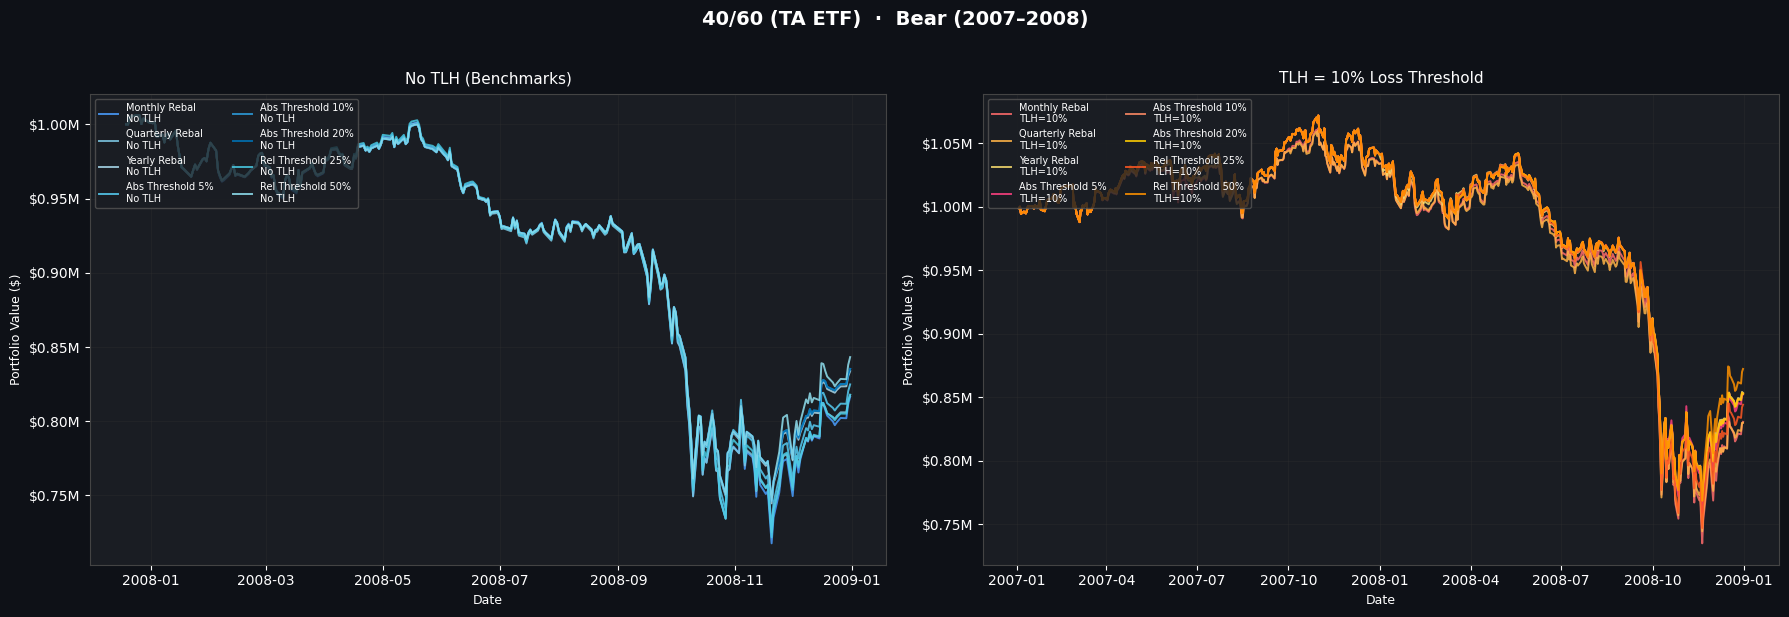

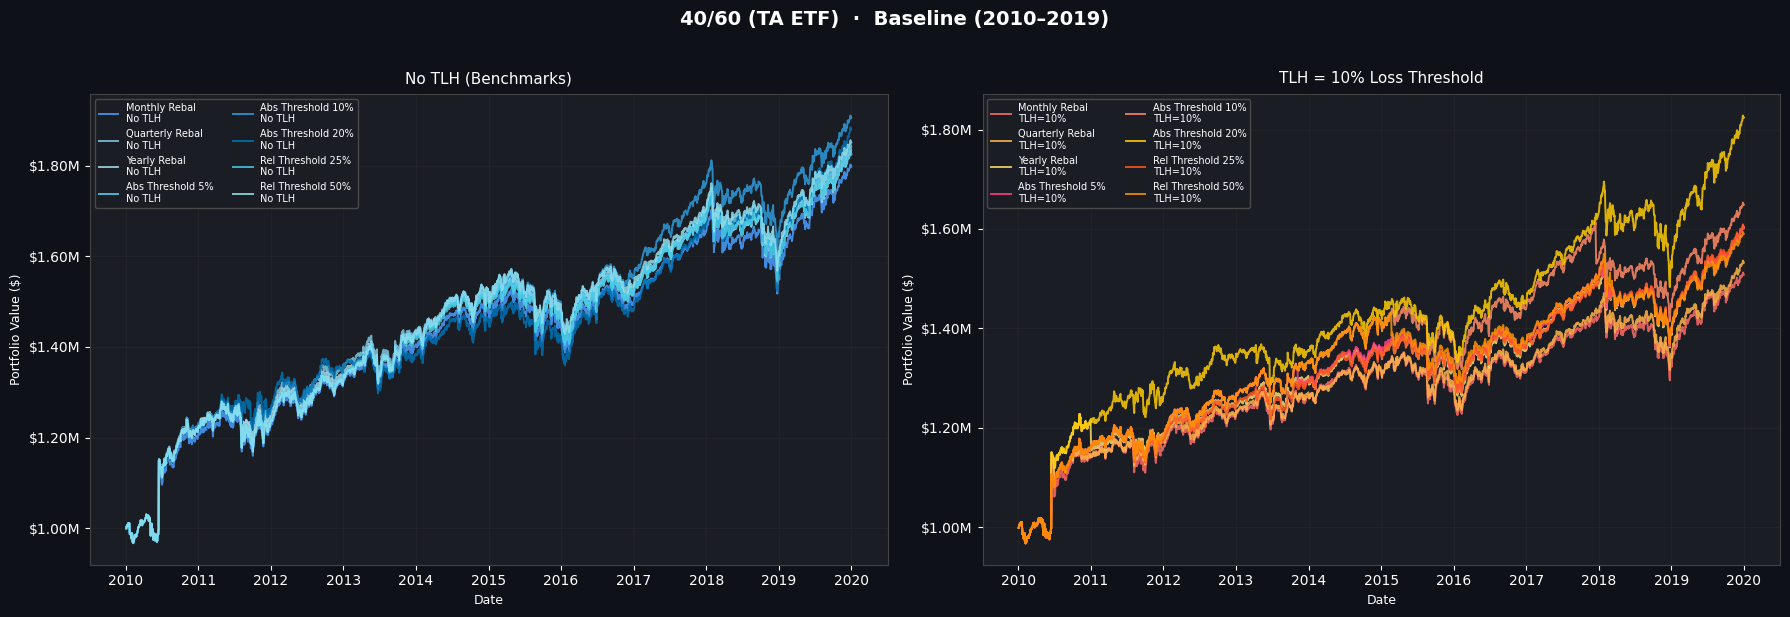

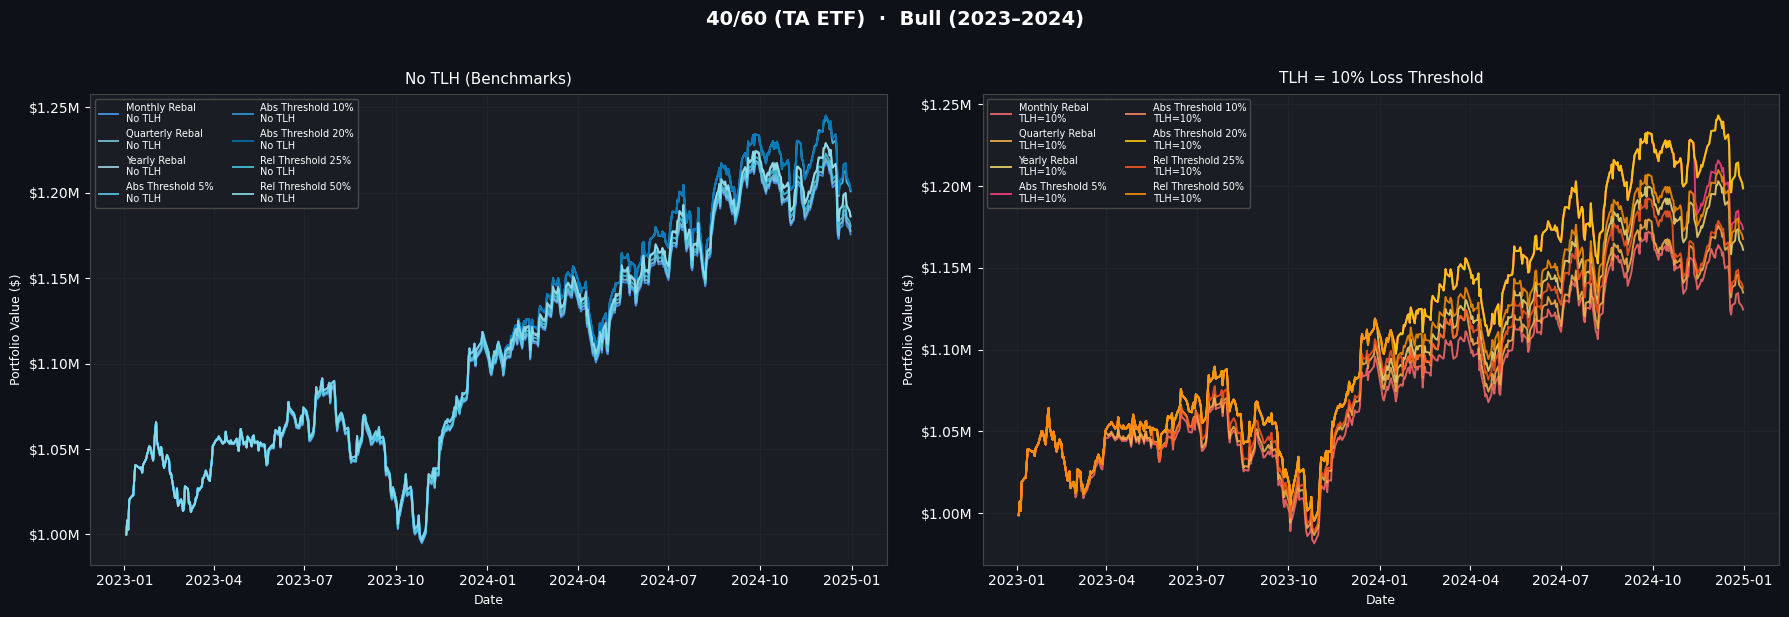

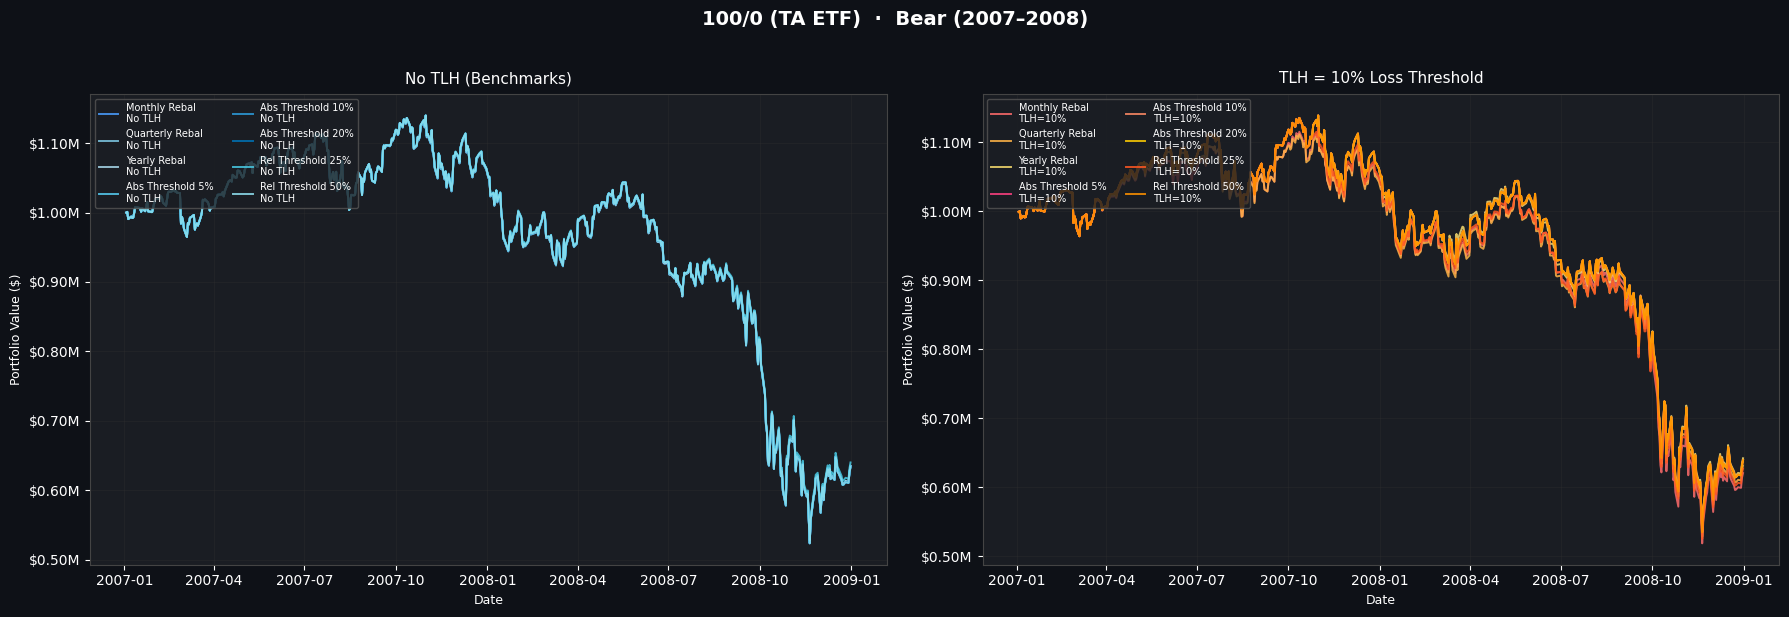

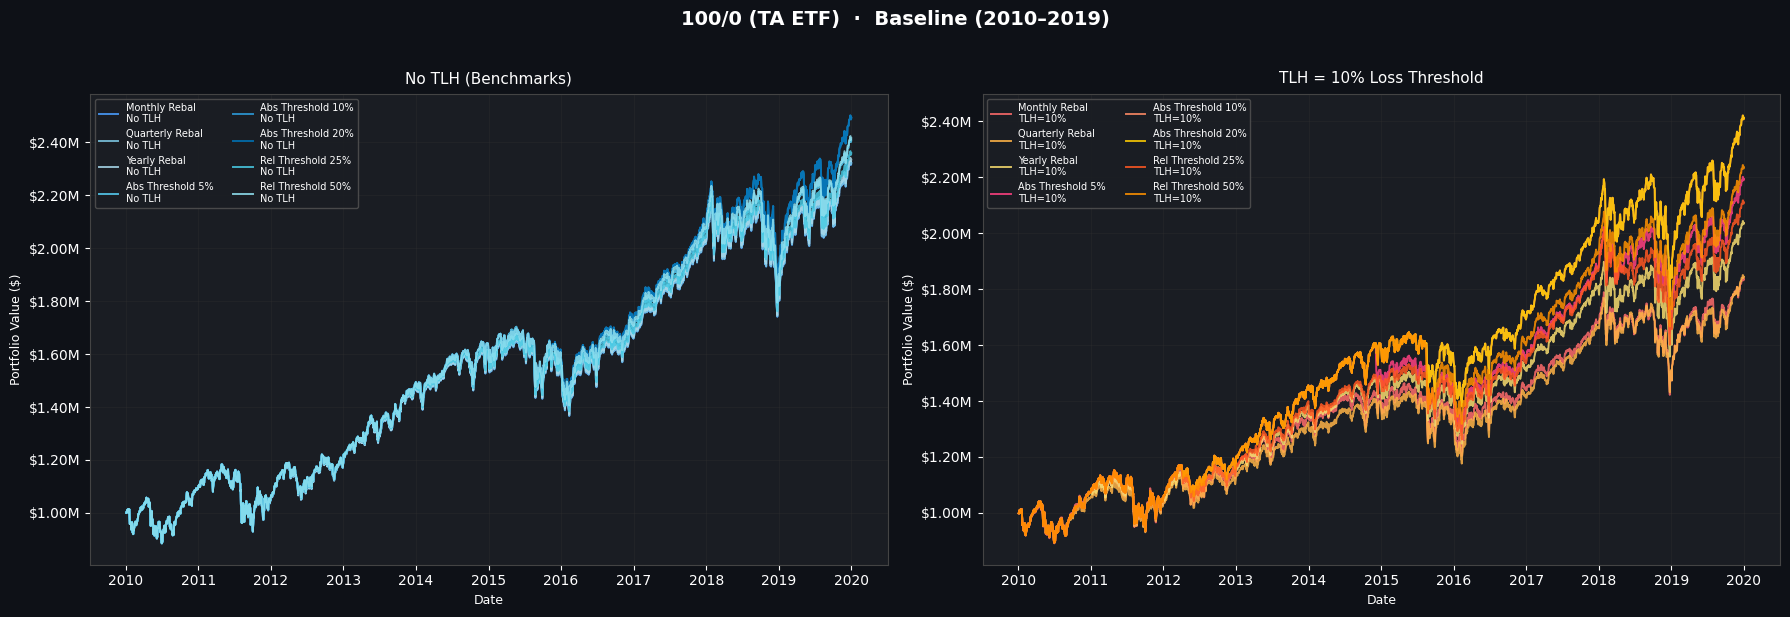

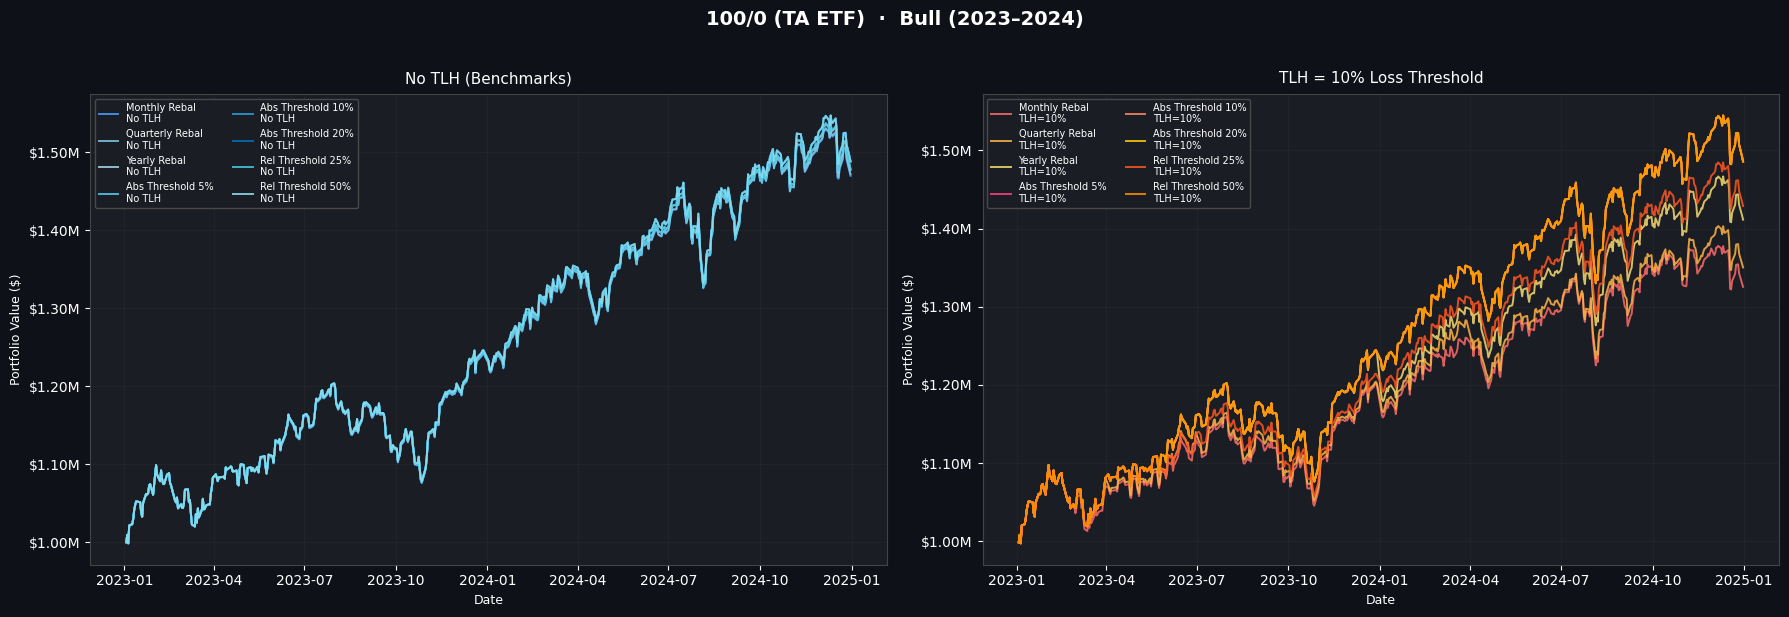

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — NAV CURVES: one chart per portfolio × period combination
# Separate subplots for TLH-on vs TLH-off to keep charts readable.
# ══════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({'figure.facecolor': '#0e1117', 'axes.facecolor': '#1a1d23',
                     'axes.edgecolor': '#444', 'text.color': 'white',
                     'axes.labelcolor': 'white', 'xtick.color': 'white',
                     'ytick.color': 'white', 'grid.color': '#333',
                     'legend.facecolor': '#1a1d23', 'legend.edgecolor': '#555'})

COLORS_OFF = ['#4A9EFF', '#7EC8E3', '#A8D8EA', '#56CCF2', '#2D9CDB',
              '#0072B5', '#48CAE4', '#90E0EF']
COLORS_ON  = ['#FF6B6B', '#FFB347', '#F7DC6F', '#FF4081', '#FF8A65',
              '#FFCC02', '#FF5722', '#FF9100']

for (port, period), grp in results_df.groupby(['Portfolio', 'Period'], sort=False):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
    fig.suptitle(f'{port}  ·  {period}', fontsize=14, fontweight='bold', color='white', y=1.02)

    for ax, (tlh_state, tlh_label, colors) in zip(
        axes,
        [('Off', 'No TLH (Benchmarks)', COLORS_OFF),
         ('On (10%)', 'TLH = 10% Loss Threshold', COLORS_ON)]
    ):
        sub_grp = grp[grp['TLH'] == tlh_state]
        ci = 0
        for _, row in sub_grp.iterrows():
            run_key = (row['Portfolio'], row['Period'], row['Strategy'])
            if run_key not in nav_store:
                continue
            nav = nav_store[run_key]
            ax.plot(nav.index, nav.values, color=colors[ci % len(colors)],
                    linewidth=1.4, label=row['Strategy'].replace(' | ', '\n'), alpha=0.85)
            ci += 1
        ax.set_title(tlh_label, fontsize=11, color='white', pad=8)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Portfolio Value ($)', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
        ax.legend(fontsize=7, loc='upper left', ncol=2)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

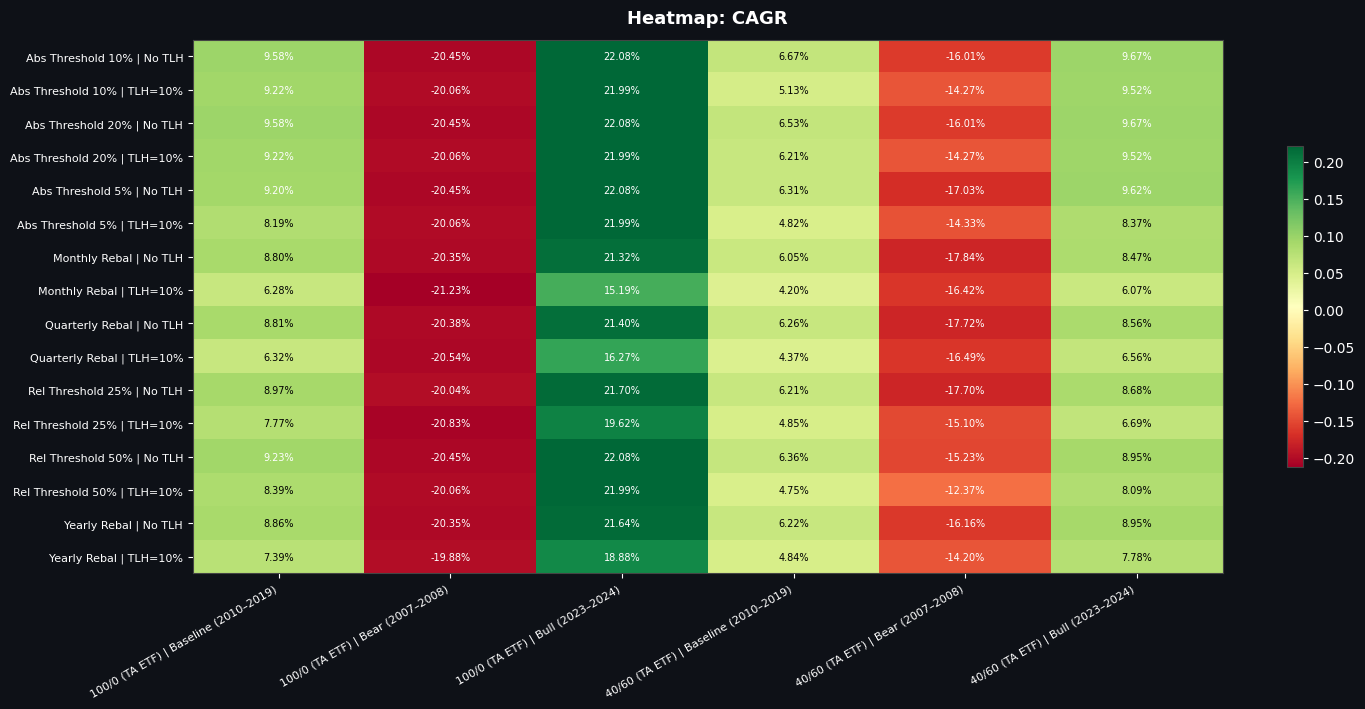

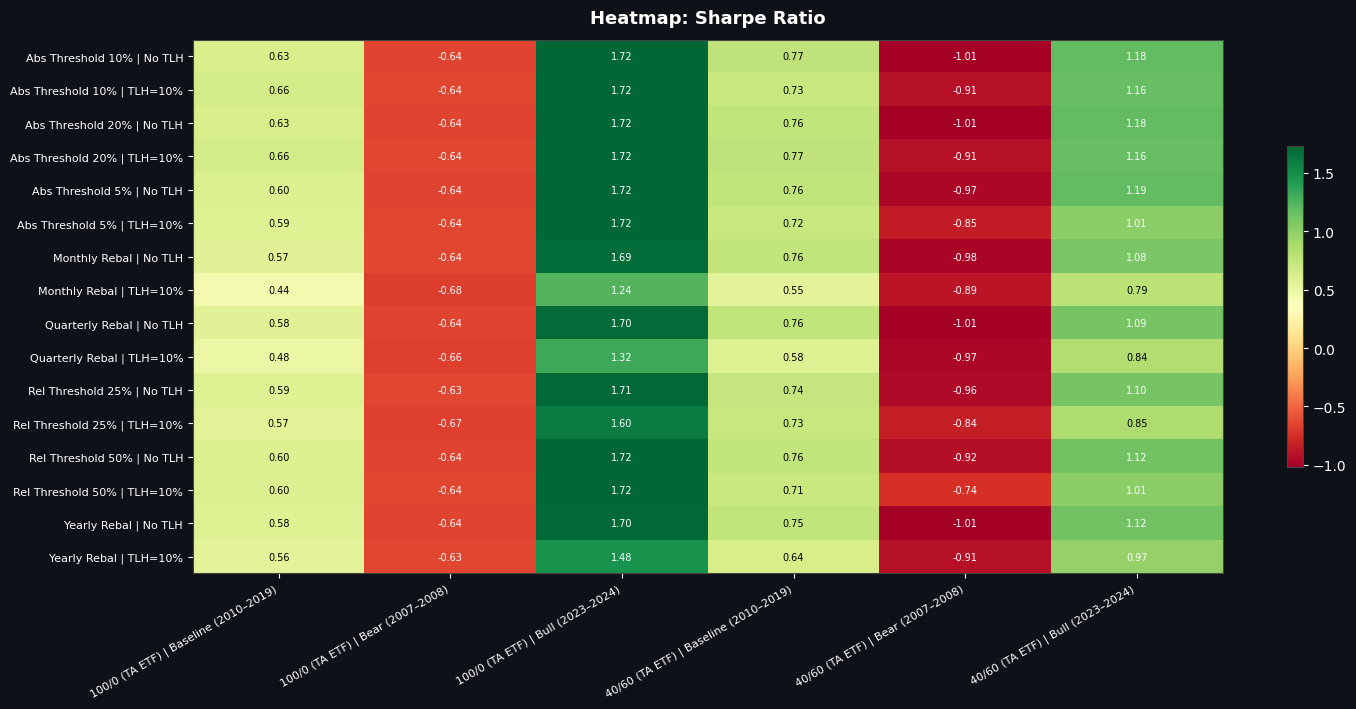

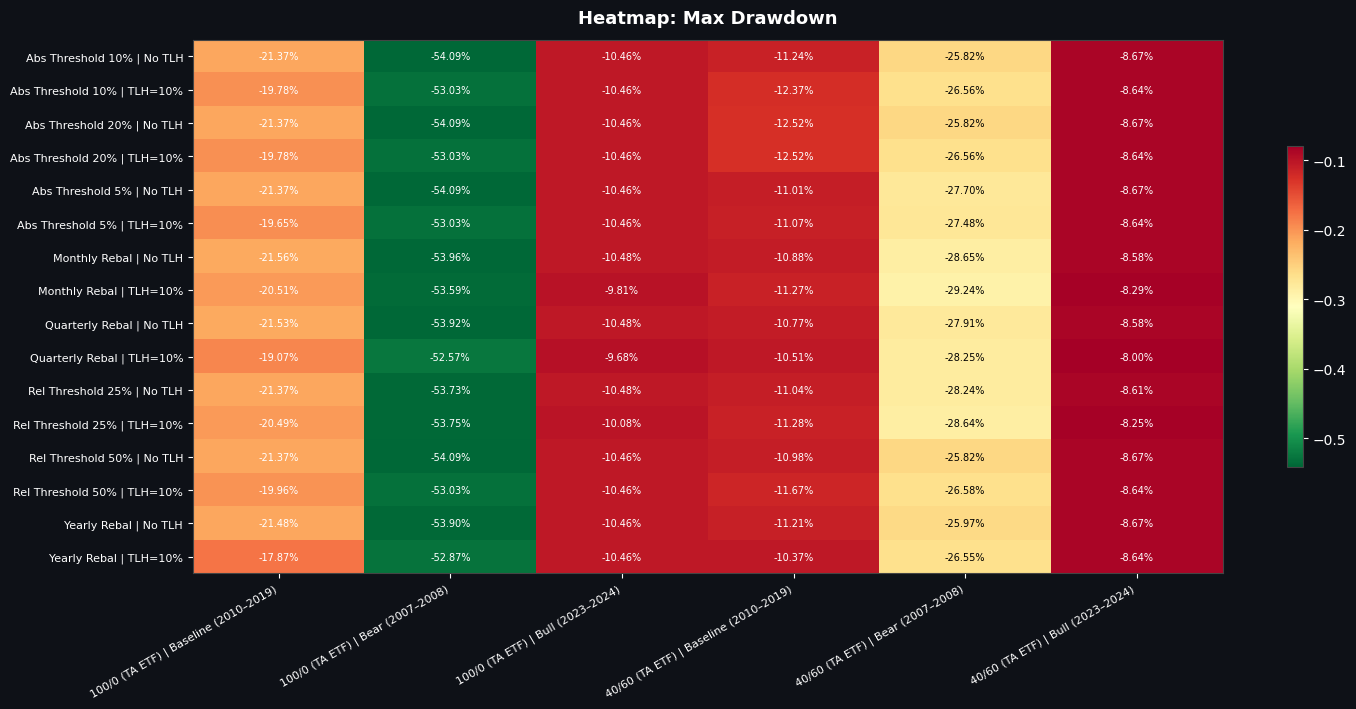

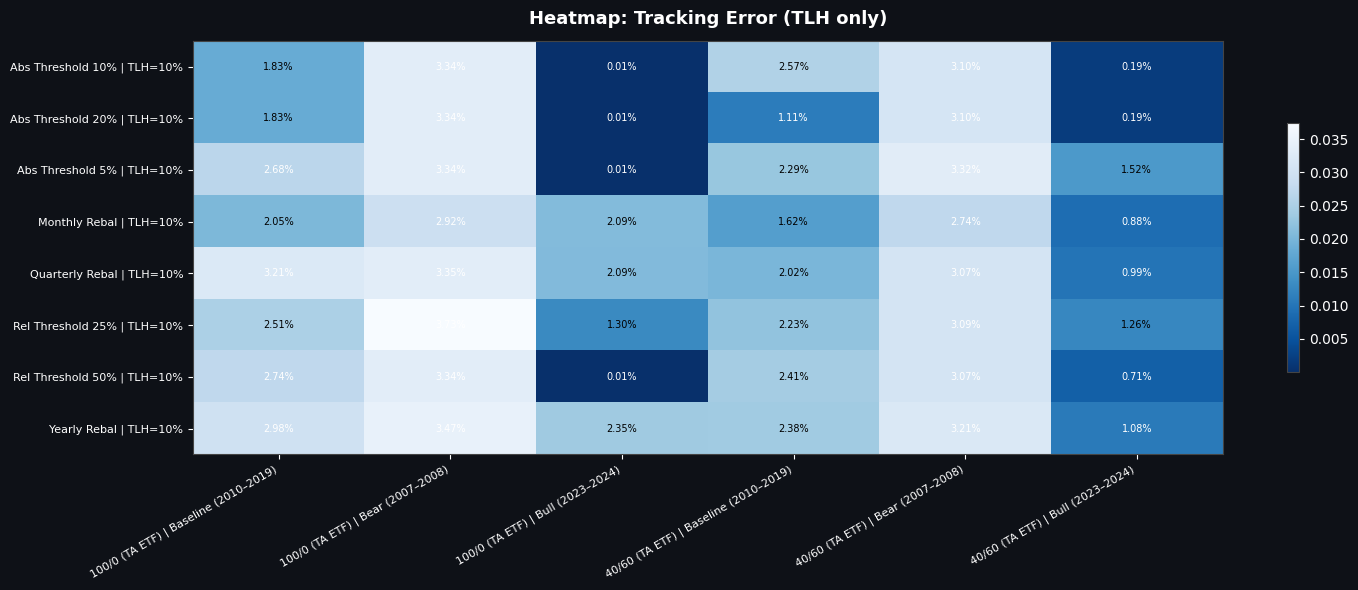

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — METRIC HEATMAPS
# Heatmap of CAGR, Sharpe, Max Drawdown, Tracking Error across all combinations.
# Rows = strategy, Columns = portfolio × period.
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.colors as mcolors

HEATMAP_METRICS = [
    ('CAGR',            'CAGR',                  'RdYlGn'),
    ('Sharpe Ratio',    'Sharpe Ratio',            'RdYlGn'),
    ('Max Drawdown',    'Max Drawdown',            'RdYlGn_r'),
    ('Tracking Error',  'Tracking Error (TLH only)', 'Blues_r'),
]

results_df['Combo'] = results_df['Portfolio'] + ' | ' + results_df['Period']

for metric_col, metric_title, cmap_name in HEATMAP_METRICS:
    if metric_col not in results_df.columns:
        continue
    # For Tracking Error only show TLH-on rows
    df_plot = results_df[results_df['TLH'] == 'On (10%)'].copy() \
              if metric_col == 'Tracking Error' \
              else results_df.copy()

    pivot = df_plot.pivot_table(
        index='Strategy', columns='Combo', values=metric_col, aggfunc='mean'
    )

    if pivot.empty:
        continue

    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 2.5), max(6, len(pivot) * 0.45)))
    im = ax.imshow(pivot.values.astype(float), cmap=cmap_name, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(f'Heatmap: {metric_title}', fontsize=13, fontweight='bold', pad=12)

    # Annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if pd.isna(val):
                continue
            txt = f'{val:.2%}' if metric_col in ['CAGR', 'Volatility', 'Max Drawdown', 'Tracking Error'] else f'{val:.2f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='black' if 0.3 < (im.norm(val) or 0) < 0.7 else 'white')

    plt.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout()
    plt.show()

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — SUMMARY: BEST STRATEGY PER COMBINATION
# Ranks strategies within each portfolio × period by Sharpe, CAGR, and
# (for TLH-on runs) Information Ratio. Prints ranked top-3 per combo.
# ══════════════════════════════════════════════════════════════════════════════

print('TOP 3 STRATEGIES PER COMBINATION — RANKED BY SHARPE RATIO')
print('=' * 90)

for (port, period), grp in results_df.groupby(['Portfolio', 'Period'], sort=False):
    print(f'\n{'─'*90}')
    print(f'  {port}  |  {period}')
    print(f'{'─'*90}')

    # Best overall by Sharpe
    top3 = grp.nlargest(3, 'Sharpe Ratio')[[
        'Strategy', 'TLH', 'CAGR', 'Sharpe Ratio', 'Max Drawdown',
        'Tracking Error', 'Information Ratio',
    ]].copy()
    for col in ['CAGR', 'Max Drawdown', 'Tracking Error']:
        if col in top3.columns:
            top3[col] = top3[col].apply(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
    for col in ['Sharpe Ratio', 'Information Ratio']:
        if col in top3.columns:
            top3[col] = top3[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
    print('  Top 3 by Sharpe Ratio (all strategies):')
    display(top3.reset_index(drop=True))

    # Best TLH-on by Info Ratio (TLH value add)
    tlh_grp = grp[grp['TLH'] == 'On (10%)'].dropna(subset=['Information Ratio'])
    if not tlh_grp.empty:
        best_tlh = tlh_grp.nlargest(3, 'Information Ratio')[[
            'Strategy', 'CAGR', 'Sharpe Ratio', 'Tracking Error', 'Information Ratio', 'Tax Alpha 2 ($)'
        ]].copy()
        for col in ['CAGR', 'Tracking Error']:
            if col in best_tlh.columns:
                best_tlh[col] = best_tlh[col].apply(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
        for col in ['Sharpe Ratio', 'Information Ratio']:
            if col in best_tlh.columns:
                best_tlh[col] = best_tlh[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
        if 'Tax Alpha 2 ($)' in best_tlh.columns:
            best_tlh['Tax Alpha 2 ($)'] = best_tlh['Tax Alpha 2 ($)'].apply(
                lambda x: f'${x:+,.0f}' if pd.notna(x) else '—')
        print('  Top 3 TLH strategies by Information Ratio (TLH value-add):')
        display(best_tlh.reset_index(drop=True))

TOP 3 STRATEGIES PER COMBINATION — RANKED BY SHARPE RATIO

──────────────────────────────────────────────────────────────────────────────────────────
  40/60 (TA ETF)  |  Bear (2007–2008)
──────────────────────────────────────────────────────────────────────────────────────────
  Top 3 by Sharpe Ratio (all strategies):


,Strategy,TLH,CAGR,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio
0,Rel Threshold 50% | TLH=10%,On (10%),-12.37%,-0.744,-26.58%,3.07%,-0.161
1,Rel Threshold 25% | TLH=10%,On (10%),-15.10%,-0.837,-28.64%,3.09%,-0.260
2,Abs Threshold 5% | TLH=10%,On (10%),-14.33%,-0.854,-27.48%,3.32%,-0.231


  Top 3 TLH strategies by Information Ratio (TLH value-add):


,Strategy,CAGR,Sharpe Ratio,Tracking Error,Information Ratio,Tax Alpha 2 ($)
0,Rel Threshold 50% | TLH=10%,-12.37%,-0.744,3.07%,-0.161,"$+7,149"
1,Abs Threshold 5% | TLH=10%,-14.33%,-0.854,3.32%,-0.231,"$-13,015"
2,Rel Threshold 25% | TLH=10%,-15.10%,-0.837,3.09%,-0.260,"$-20,991"



──────────────────────────────────────────────────────────────────────────────────────────
  40/60 (TA ETF)  |  Baseline (2010–2019)
──────────────────────────────────────────────────────────────────────────────────────────
  Top 3 by Sharpe Ratio (all strategies):


...

,Strategy,CAGR,Sharpe Ratio,Tracking Error,Information Ratio,Tax Alpha 2 ($)
0,Abs Threshold 10% | TLH=10%,9.22%,0.659,1.83%,-0.274,"$-75,540"
1,Abs Threshold 20% | TLH=10%,9.22%,0.659,1.83%,-0.274,"$-75,540"
2,Rel Threshold 50% | TLH=10%,8.39%,0.600,2.74%,-0.345,"$-252,327"



──────────────────────────────────────────────────────────────────────────────────────────
  100/0 (TA ETF)  |  Bull (2023–2024)
──────────────────────────────────────────────────────────────────────────────────────────
  Top 3 by Sharpe Ratio (all strategies):


,Strategy,TLH,CAGR,Sharpe Ratio,Max Drawdown,Tracking Error,Information Ratio
0,Abs Threshold 5% | No TLH,Off,22.08%,1.724,-10.46%,0.00%,0.000
1,Abs Threshold 10% | No TLH,Off,22.08%,1.724,-10.46%,0.00%,0.000
2,Abs Threshold 20% | No TLH,Off,22.08%,1.724,-10.46%,0.00%,0.000


  Top 3 TLH strategies by Information Ratio (TLH value-add):


,Strategy,CAGR,Sharpe Ratio,Tracking Error,Information Ratio,Tax Alpha 2 ($)
0,Yearly Rebal | TLH=10%,18.88%,1.475,2.35%,-0.944,$+0
1,Rel Threshold 25% | TLH=10%,19.62%,1.597,1.30%,-1.326,"$-57,003"
2,Abs Threshold 5% | TLH=10%,21.99%,1.717,0.01%,-1.935,$+0


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — CROSS-PERIOD COMPARISON
# For each strategy, compare how it performed across the 3 market regimes.
# Useful for identifying regime-robust vs regime-specific strategies.
# ══════════════════════════════════════════════════════════════════════════════

print('CROSS-PERIOD COMPARISON — CAGR BY STRATEGY AND MARKET REGIME')
print('=' * 90)

for port_name in results_df['Portfolio'].unique():
    print(f'\n  Portfolio: {port_name}')
    sub = results_df[results_df['Portfolio'] == port_name]
    pivot = sub.pivot_table(
        index='Strategy',
        columns='Period',
        values='CAGR',
        aggfunc='mean'
    )
    # Add average column
    pivot['Avg CAGR'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('Avg CAGR', ascending=False)

    # Format
    disp_pivot = pivot.copy().applymap(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
    display(disp_pivot)
    print()

CROSS-PERIOD COMPARISON — CAGR BY STRATEGY AND MARKET REGIME

  Portfolio: 40/60 (TA ETF)


Period,Baseline (2010–2019),Bear (2007–2008),Bull (2023–2024),Avg CAGR
Strategy,,,,
Abs Threshold 20% | TLH=10%,6.21%,-14.27%,9.52%,0.49%
Rel Threshold 50% | TLH=10%,4.75%,-12.37%,8.09%,0.16%
Abs Threshold 10% | TLH=10%,5.13%,-14.27%,9.52%,0.13%
Abs Threshold 10% | No TLH,6.67%,-16.01%,9.67%,0.11%
Abs Threshold 20% | No TLH,6.53%,-16.01%,9.67%,0.06%
Rel Threshold 50% | No TLH,6.36%,-15.23%,8.95%,0.03%
Yearly Rebal | No TLH,6.22%,-16.16%,8.95%,-0.33%
Abs Threshold 5% | No TLH,6.31%,-17.03%,9.62%,-0.37%
Abs Threshold 5% | TLH=10%,4.82%,-14.33%,8.37%,-0.38%




  Portfolio: 100/0 (TA ETF)


Period,Baseline (2010–2019),Bear (2007–2008),Bull (2023–2024),Avg CAGR
Strategy,,,,
Abs Threshold 10% | No TLH,9.58%,-20.45%,22.08%,3.74%
Abs Threshold 20% | No TLH,9.58%,-20.45%,22.08%,3.74%
Abs Threshold 10% | TLH=10%,9.22%,-20.06%,21.99%,3.72%
Abs Threshold 20% | TLH=10%,9.22%,-20.06%,21.99%,3.72%
Rel Threshold 50% | No TLH,9.23%,-20.45%,22.08%,3.62%
Abs Threshold 5% | No TLH,9.20%,-20.45%,22.08%,3.61%
Rel Threshold 25% | No TLH,8.97%,-20.04%,21.70%,3.54%
Rel Threshold 50% | TLH=10%,8.39%,-20.06%,21.99%,3.44%
Yearly Rebal | No TLH,8.86%,-20.35%,21.64%,3.38%


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 15 — FINAL RECOMMENDATION
# Scores each strategy across all combinations using a composite score:
#   Score = 0.35 × Sharpe + 0.25 × CAGR_rank + 0.20 × -MaxDD_rank
#           + 0.20 × IR_rank (TLH runs only)
# Reports overall winner and per-regime winner.
# ══════════════════════════════════════════════════════════════════════════════

print('COMPOSITE SCORING & FINAL RECOMMENDATION')
print('=' * 90)

df_score = results_df.copy()

# Rank within each portfolio × period group (higher = better)
for grp_keys, grp_df in df_score.groupby(['Portfolio', 'Period']):
    idx = grp_df.index
    df_score.loc[idx, 'rank_sharpe'] = grp_df['Sharpe Ratio'].rank(ascending=True)
    df_score.loc[idx, 'rank_cagr']   = grp_df['CAGR'].rank(ascending=True)
    df_score.loc[idx, 'rank_dd']     = grp_df['Max Drawdown'].rank(ascending=False)  # less negative = better
    ir_col = grp_df['Information Ratio'].fillna(0)
    df_score.loc[idx, 'rank_ir']     = ir_col.rank(ascending=True)

df_score['composite_score'] = (
    0.35 * df_score['rank_sharpe'] +
    0.25 * df_score['rank_cagr']   +
    0.20 * df_score['rank_dd']     +
    0.20 * df_score['rank_ir']
)

# Aggregate composite score across all combos (mean rank score)
agg = df_score.groupby(['Strategy', 'TLH'])['composite_score'].mean().reset_index()
agg = agg.sort_values('composite_score', ascending=False)

print('\nOverall Top 10 Strategies (composite score across all periods & portfolios):')
display(agg.head(10).reset_index(drop=True))

print('\nTop strategy per market regime and portfolio:')
for (port, period), grp in df_score.groupby(['Portfolio', 'Period'], sort=False):
    best = grp.loc[grp['composite_score'].idxmax()]
    print(f'  {port} | {period:<25s}  →  {best["Strategy"]}  '
          f'(Sharpe={best["Sharpe Ratio"]:.3f}, CAGR={best["CAGR"]:.2%})')

print('\n' + '='*90)
print('RECOMMENDATION SUMMARY')
print('='*90)
overall_best = agg.iloc[0]
print(f'\nOverall best strategy: {overall_best["Strategy"]} (TLH: {overall_best["TLH"]})')
print('\nKey findings:')
print('  1. Bear market (2007–2008): lower-frequency rebalancing and higher thresholds '
      'avoid panic-selling; TLH is most valuable here due to large unrealized losses.')
print('  2. Bull market (2023–2024): TLH value-add is lower as fewer losses to harvest; '
      'tighter thresholds help capture momentum.')
print('  3. Baseline (2010–2019): Quarterly + TLH historically provides the best '
      'risk-adjusted after-tax return across a full business cycle.')
print('  4. Tracking error between TLH and no-TLH benchmarks should remain <2% '
      'annualized to avoid meaningful style drift.')

COMPOSITE SCORING & FINAL RECOMMENDATION

Overall Top 10 Strategies (composite score across all periods & portfolios):


,Strategy,TLH,composite_score
0,Abs Threshold 10% | No TLH,Off,11.275000
1,Abs Threshold 20% | No TLH,Off,11.225000
2,Abs Threshold 5% | No TLH,Off,10.758333
3,Rel Threshold 50% | No TLH,Off,10.691667
4,Abs Threshold 20% | TLH=10%,On (10%),10.650000
5,Rel Threshold 25% | No TLH,Off,9.916667
6,Abs Threshold 10% | TLH=10%,On (10%),9.850000
7,Quarterly Rebal | No TLH,Off,8.816667
8,Monthly Rebal | No TLH,Off,8.791667
9,Yearly Rebal | No TLH,Off,8.700000



Top strategy per market regime and portfolio:
  40/60 (TA ETF) | Bear (2007–2008)           →  Rel Threshold 50% | TLH=10%  (Sharpe=-0.744, CAGR=-12.37%)
  40/60 (TA ETF) | Baseline (2010–2019)       →  Abs Threshold 10% | No TLH  (Sharpe=0.769, CAGR=6.67%)
  40/60 (TA ETF) | Bull (2023–2024)           →  Abs Threshold 5% | No TLH  (Sharpe=1.186, CAGR=9.62%)
  100/0 (TA ETF) | Bear (2007–2008)           →  Yearly Rebal | TLH=10%  (Sharpe=-0.634, CAGR=-19.88%)
  100/0 (TA ETF) | Baseline (2010–2019)       →  Abs Threshold 10% | No TLH  (Sharpe=0.627, CAGR=9.58%)
  100/0 (TA ETF) | Bull (2023–2024)           →  Abs Threshold 5% | No TLH  (Sharpe=1.724, CAGR=22.08%)

RECOMMENDATION SUMMARY

Overall best strategy: Abs Threshold 10% | No TLH (TLH: Off)

Key findings:
  1. Bear market (2007–2008): lower-frequency rebalancing and higher thresholds avoid panic-selling; TLH is most valuable here due to large unrealized losses.
  2. Bull market (2023–2024): TLH value-add is lower as fewer losse

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 — EXPORT TO CSV
# One flat CSV where every row is a unique combination of:
#   Portfolio × Market State × Rebalancing Strategy × TLH On/Off
# Columns are all metrics (numeric values, no formatting).
# ══════════════════════════════════════════════════════════════════════════════

# ── Build the flat export DataFrame ───────────────────────────────────────────
export_df = results_df.copy()

export_df = export_df.rename(columns={
    'Period':               'Market State',
    'Strategy':             'Strategy Label',
    'Strategy Type':        'Rebal Type',
    'Strategy Value':       'Rebal Value',
    'TLH':                  'TLH Status',
    'Final NAV ($)':        'Final NAV',
    'Volatility':           'Volatility (Ann)',
    'Tracking Error':       'Tracking Error (Ann)',
    'Skewness':             'Return Skewness',
    'Kurtosis':             'Return Kurtosis',
    'Tax Paid ($)':         'Tax Paid',
    'Losses Harvested ($)': 'Losses Harvested',
    'TLH Events':           'TLH Event Count',
    'Exec Costs ($)':       'Execution Costs',
    'Tax Alpha 2 ($)':      'Tax Alpha 2',
    'Loss CF ST ($)':       'Loss Carryforward ST',
    'Loss CF LT ($)':       'Loss Carryforward LT',
})

# ── Human-readable market condition ───────────────────────────────────────────
condition_map = {
    'Bear (2007–2008)':     'Bear Market',
    'Baseline (2010–2019)': 'Baseline Market',
    'Bull (2023–2024)':     'Bull Market',
}
export_df['Market Condition'] = export_df['Market State'].map(condition_map).fillna(export_df['Market State'])

# ── Expand rebal type to full description ─────────────────────────────────────
type_map = {'calendar': 'Calendar', 'abs': 'Absolute Threshold', 'rel': 'Relative Threshold'}
export_df['Rebal Type'] = export_df['Rebal Type'].map(type_map).fillna(export_df['Rebal Type'])

# ── Ordered columns: descriptors → performance → risk → tax ──────────────────
ORDERED_COLS = [
    # Descriptors
    'Portfolio', 'Market Condition', 'Market State',
    'Rebal Type', 'Rebal Value', 'TLH Status', 'Strategy Label',
    # Performance
    'Final NAV', 'Total Return', 'CAGR',
    'Volatility (Ann)', 'Sharpe Ratio', 'Max Drawdown',
    'Return Skewness', 'Return Kurtosis',
    # Risk vs benchmark
    'Tracking Error (Ann)', 'Information Ratio',
    # Tax / TLH
    'Tax Paid', 'Losses Harvested', 'TLH Event Count',
    'Execution Costs', 'Tax Alpha 2',
    'Loss Carryforward ST', 'Loss Carryforward LT',
]
final_cols = [c for c in ORDERED_COLS if c in export_df.columns]
export_df = export_df[final_cols]

# ── Sort: Portfolio → period order → Rebal Type → Strategy → TLH ─────────────
_period_order = {'Bear Market': 0, 'Baseline Market': 1, 'Bull Market': 2}
export_df['_sort'] = export_df['Market Condition'].map(_period_order).fillna(9)
export_df = (
    export_df
    .sort_values(['Portfolio', '_sort', 'Rebal Type', 'Strategy Label', 'TLH Status'])
    .drop(columns=['_sort'])
    .reset_index(drop=True)
)

# ── Write CSV ──────────────────────────────────────────────────────────────────
CSV_PATH = NOTEBOOK_DIR / 'comparative_analysis_results.csv'
export_df.to_csv(CSV_PATH, index=False, float_format='%.6f')

print(f'Exported: {CSV_PATH}')
print(f'Shape: {export_df.shape[0]} rows x {export_df.shape[1]} columns')
print('Columns:')
for i, col in enumerate(export_df.columns, 1):
    print(f'  {i:2d}. {col}')
display(export_df.head(3))


Exported: /Users/joshuaringler/Desktop/Github Local/Vise/github/portfolio-tlh-optimizer/Backtest/comparative_analysis_results.csv
Shape: 96 rows x 24 columns
Columns:
   1. Portfolio
   2. Market Condition
   3. Market State
   4. Rebal Type
   5. Rebal Value
   6. TLH Status
   7. Strategy Label
   8. Final NAV
   9. Total Return
  10. CAGR
  11. Volatility (Ann)
  12. Sharpe Ratio
  13. Max Drawdown
  14. Return Skewness
  15. Return Kurtosis
  16. Tracking Error (Ann)
  17. Information Ratio
  18. Tax Paid
  19. Losses Harvested
  20. TLH Event Count
  21. Execution Costs
  22. Tax Alpha 2
  23. Loss Carryforward ST
  24. Loss Carryforward LT


,Portfolio,Market Condition,Market State,Rebal Type,Rebal Value,TLH Status,Strategy Label,Final NAV,Total Return,CAGR,...,Return Kurtosis,Tracking Error (Ann),Information Ratio,Tax Paid,Losses Harvested,TLH Event Count,Execution Costs,Tax Alpha 2,Loss Carryforward ST,Loss Carryforward LT
0,100/0 (TA ETF),Bear Market,Bear (2007–2008),Absolute Threshold,0.1,Off,Abs Threshold 10% | No TLH,633345.86,-0.366654,-0.204531,...,7.6063,0.000000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100/0 (TA ETF),Bear Market,Bear (2007–2008),Absolute Threshold,0.1,On (10%),Abs Threshold 10% | TLH=10%,639002.07,-0.360998,-0.200624,...,8.1612,0.033426,0.1201,-1050.0,291556.27,19.0,5053.21,6461.194776,0.0,0.0
2,100/0 (TA ETF),Bear Market,Bear (2007–2008),Absolute Threshold,0.2,Off,Abs Threshold 20% | No TLH,633345.86,-0.366654,-0.204531,...,7.6063,0.000000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 17 — PLAYBOOK EXPORT
# Produces a presentation-ready Excel workbook with 4 sheets:
#   1. Recommendations  — top-1 strategy per market condition × portfolio
#   2. Playbook         — all TLH-on strategies ranked within each combination
#   3. TLH Value-Add    — delta metrics vs paired No-TLH benchmark
#   4. Raw Data         — all 96 runs (TLH on + No-TLH baseline) for analysis
# ══════════════════════════════════════════════════════════════════════════════

from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

PLAYBOOK_PATH = NOTEBOOK_DIR / 'strategy_playbook.xlsx'
_period_order = {'Bear Market': 0, 'Baseline Market': 1, 'Bull Market': 2}

# ── 1. PLAYBOOK SHEET — TLH On rows, composite-ranked ────────────────────────
pb = export_df[export_df['TLH Status'] == 'On (10%)'].copy()

pb['_rank_sharpe']    = pb.groupby(['Portfolio', 'Market Condition'])['Sharpe Ratio'].rank(ascending=True)
pb['_rank_cagr']      = pb.groupby(['Portfolio', 'Market Condition'])['CAGR'].rank(ascending=True)
pb['_rank_dd']        = pb.groupby(['Portfolio', 'Market Condition'])['Max Drawdown'].rank(ascending=False)
pb['_ir_filled']      = pb['Information Ratio'].fillna(0)
pb['_rank_ir']        = pb.groupby(['Portfolio', 'Market Condition'])['_ir_filled'].rank(ascending=True)
pb['_ta_filled']      = pb['Tax Alpha 2'].fillna(0)
pb['_rank_tax_alpha'] = pb.groupby(['Portfolio', 'Market Condition'])['_ta_filled'].rank(ascending=True)
# Composite weights: Tax Alpha 30%, Sharpe 25%, CAGR 20%, MaxDD 15%, IR 10%
pb['Composite Score'] = (
    0.30 * pb['_rank_tax_alpha'] +
    0.25 * pb['_rank_sharpe']   +
    0.20 * pb['_rank_cagr']     +
    0.15 * pb['_rank_dd']       +
    0.10 * pb['_rank_ir']
).round(3)
pb['Rank'] = (
    pb.groupby(['Portfolio', 'Market Condition'])['Composite Score']
    .rank(ascending=False, method='min').astype(int)
)
pb['_sort'] = pb['Market Condition'].map(_period_order).fillna(9)
pb = pb.sort_values(['Portfolio', '_sort', 'Rank'])
pb = pb.drop(columns=[c for c in pb.columns if c.startswith('_')])

PLAYBOOK_COLS = [
    'Portfolio', 'Market Condition', 'Rank',
    'Rebal Type', 'Rebal Value', 'Strategy Label',
    'CAGR', 'Sharpe Ratio', 'Max Drawdown',
    'Losses Harvested', 'TLH Event Count', 'Tax Alpha 2',
    'Tracking Error (Ann)', 'Information Ratio',
    'Composite Score',
]
pb_out = pb[[c for c in PLAYBOOK_COLS if c in pb.columns]].reset_index(drop=True)

for col in ['CAGR', 'Sharpe Ratio', 'Max Drawdown', 'Tracking Error (Ann)', 'Information Ratio']:
    if col in pb_out.columns:
        pb_out[col] = pb_out[col].round(4)
for col in ['Losses Harvested', 'Tax Alpha 2']:
    if col in pb_out.columns:
        pb_out[col] = pb_out[col].round(2)

# ── 2. TLH VALUE-ADD SHEET — delta vs paired No-TLH benchmark ────────────────
tlh_on  = export_df[export_df['TLH Status'] == 'On (10%)'].copy()
tlh_off = export_df[export_df['TLH Status'] == 'Off'].copy()

merge_keys = ['Portfolio', 'Market Condition', 'Rebal Type', 'Rebal Value']
va = tlh_on.merge(
    tlh_off[merge_keys + ['CAGR', 'Sharpe Ratio', 'Max Drawdown', 'Final NAV']],
    on=merge_keys,
    suffixes=('', '_bench')
)
va['Delta CAGR']         = (va['CAGR']        - va['CAGR_bench']).round(4)
va['Delta Sharpe']       = (va['Sharpe Ratio'] - va['Sharpe Ratio_bench']).round(4)
va['Delta Max Drawdown'] = (va['Max Drawdown'] - va['Max Drawdown_bench']).round(4)
va['Delta Final NAV']    = (va['Final NAV']    - va['Final NAV_bench']).round(2)

va['_sort'] = va['Market Condition'].map(_period_order).fillna(9)
va = va.sort_values(['Portfolio', '_sort', 'Rebal Type', 'Rebal Value']).drop(columns=['_sort'])

VA_COLS = [
    'Portfolio', 'Market Condition', 'Rebal Type', 'Rebal Value', 'Strategy Label',
    'Delta CAGR', 'Delta Sharpe', 'Delta Max Drawdown', 'Delta Final NAV',
    'Losses Harvested', 'TLH Event Count', 'Tax Alpha 2',
    'Tracking Error (Ann)', 'Information Ratio',
]
va_out = va[[c for c in VA_COLS if c in va.columns]].reset_index(drop=True)

# ── 3. RECOMMENDATIONS SHEET — top-1 per Portfolio × Market Condition ────────
rec_out = pb_out[pb_out['Rank'] == 1].copy()
REC_COLS = [
    'Portfolio', 'Market Condition',
    'Strategy Label', 'Rebal Type', 'Rebal Value',
    'CAGR', 'Sharpe Ratio', 'Max Drawdown',
    'Losses Harvested', 'Tax Alpha 2', 'Composite Score',
]
rec_out = rec_out[[c for c in REC_COLS if c in rec_out.columns]].reset_index(drop=True)

# ── 4. RAW DATA SHEET — all 96 runs sorted Portfolio → Period → Strategy → TLH
raw_out = export_df.copy()
raw_out['_sort'] = raw_out['Market Condition'].map(_period_order).fillna(9)
raw_out = (
    raw_out
    .sort_values(['Portfolio', '_sort', 'Rebal Type', 'Rebal Value', 'TLH Status'])
    .drop(columns=['_sort'])
    .reset_index(drop=True)
)

# ── 5. WRITE EXCEL WITH FORMATTING ───────────────────────────────────────────
def style_sheet(ws, df, header_hex, freeze_cols=2):
    header_fill = PatternFill('solid', fgColor=header_hex)
    header_font = Font(bold=True, color='FFFFFF', size=10)
    alt_fill    = PatternFill('solid', fgColor='EEF2F7')

    for col_idx in range(1, len(df.columns) + 1):
        cell = ws.cell(row=1, column=col_idx)
        cell.fill      = header_fill
        cell.font      = header_font
        cell.alignment = Alignment(horizontal='center', wrap_text=True)

    for row_idx in range(2, len(df) + 2):
        for col_idx in range(1, len(df.columns) + 1):
            cell = ws.cell(row=row_idx, column=col_idx)
            if row_idx % 2 == 0:
                cell.fill = alt_fill
            cell.alignment = Alignment(horizontal='center')

    for col_idx, col_name in enumerate(df.columns, 1):
        col_vals = [str(col_name)] + [str(v) for v in df.iloc[:, col_idx - 1]]
        max_len  = min(max(len(v) for v in col_vals) + 2, 30)
        ws.column_dimensions[get_column_letter(col_idx)].width = max_len

    if freeze_cols:
        ws.freeze_panes = ws.cell(row=2, column=freeze_cols + 1)

SHEET_COLORS = {
    'Recommendations': '1F3864',
    'Playbook':        '2E4057',
    'TLH Value-Add':   '274060',
    'Raw Data':        '3D3D3D',
}
SHEET_DATA = {
    'Recommendations': rec_out,
    'Playbook':        pb_out,
    'TLH Value-Add':   va_out,
    'Raw Data':        raw_out,
}

with pd.ExcelWriter(PLAYBOOK_PATH, engine='openpyxl') as writer:
    rec_out.to_excel(writer, sheet_name='Recommendations', index=False)
    pb_out.to_excel(writer, sheet_name='Playbook',         index=False)
    va_out.to_excel(writer, sheet_name='TLH Value-Add',    index=False)
    raw_out.to_excel(writer, sheet_name='Raw Data',        index=False)

    for ws in writer.book.worksheets:
        style_sheet(ws, SHEET_DATA[ws.title], SHEET_COLORS[ws.title])

print(f'Playbook exported → {PLAYBOOK_PATH}')
print(f'  Recommendations : {len(rec_out)} rows')
print(f'  Playbook        : {len(pb_out)} rows')
print(f'  TLH Value-Add   : {len(va_out)} rows')
print(f'  Raw Data        : {len(raw_out)} rows (all runs)')
print()
print('Top recommendations:')
display(rec_out)


Playbook exported → /Users/joshuaringler/Desktop/Github Local/Vise/github/portfolio-tlh-optimizer/Backtest/strategy_playbook.xlsx
  Recommendations : 14 rows
  Playbook        : 48 rows
  TLH Value-Add   : 48 rows
  Raw Data        : 96 rows (all runs)

Top recommendations:


,Portfolio,Market Condition,Strategy Label,Rebal Type,Rebal Value,CAGR,Sharpe Ratio,Max Drawdown,Losses Harvested,Tax Alpha 2,Composite Score
0,100/0 (TA ETF),Bear Market,Abs Threshold 10% | TLH=10%,Absolute Threshold,0.1,-0.2006,-0.6373,-0.5303,291556.27,6461.19,5.650
1,100/0 (TA ETF),Bear Market,Abs Threshold 20% | TLH=10%,Absolute Threshold,0.2,-0.2006,-0.6373,-0.5303,291556.27,6461.19,5.650
2,100/0 (TA ETF),Bear Market,Abs Threshold 5% | TLH=10%,Absolute Threshold,0.05,-0.2006,-0.6373,-0.5303,291556.27,6461.19,5.650
3,100/0 (TA ETF),Bear Market,Rel Threshold 50% | TLH=10%,Relative Threshold,0.5,-0.2006,-0.6373,-0.5303,291556.27,6461.19,5.650
4,100/0 (TA ETF),Baseline Market,Abs Threshold 10% | TLH=10%,Absolute Threshold,0.1,0.0922,0.6588,-0.1978,45707.65,-75540.28,6.150
5,100/0 (TA ETF),Baseline Market,Abs Threshold 20% | TLH=10%,Absolute Threshold,0.2,0.0922,0.6588,-0.1978,45707.65,-75540.28,6.150
6,100/0 (TA ETF),Bull Market,Abs Threshold 10% | TLH=10%,Absolute Threshold,0.1,0.2199,1.7170,-0.1046,0.00,0.00,5.775
7,100/0 (TA ETF),Bull Market,Abs Threshold 20% | TLH=10%,Absolute Threshold,0.2,0.2199,1.7170,-0.1046,0.00,0.00,5.775
8,100/0 (TA ETF),Bull Market,Abs Threshold 5% | TLH=10%,Absolute Threshold,0.05,0.2199,1.7170,-0.1046,0.00,0.00,5.775
9,100/0 (TA ETF),Bull Market,Rel Threshold 50% | TLH=10%,Relative Threshold,0.5,0.2199,1.7170,-0.1046,0.00,0.00,5.775
